In [9]:
from pathlib import Path
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt

import pickle
import altair as alt

### Load the file output by the process_icesat2.ipynb

In [40]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

In [41]:
sierras = gpd.read_file('../../data/misc/sierra_simplified.geojson')

In [44]:
atl06sr_gdf = atl06sr_gdf.clip(sierras.to_crs(atl06sr_gdf.crs))

<Axes: >

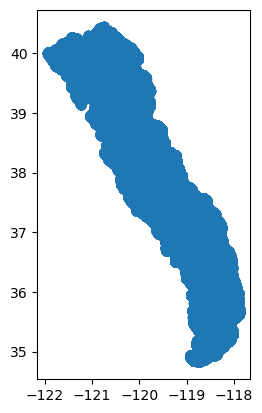

In [ ]:
atl06sr_gdf.plot()

In [90]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [89]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Get timeseries of median/average reanalysis snow depth:

In [91]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [92]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [93]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) ))

In [94]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [95]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [96]:
# 4. Apply mask
swe_sca_ds_roi = swe_sca_ds.where(mask)

In [97]:
# 5. Compute spatial median
median_sd = swe_sca_ds_roi.median(dim=('lat', 'lon'), skipna=True).compute()

### Define elevation and slope bins: 

In [18]:
elev_min = np.arange(1000, 4400, 200)
elev_max = np.arange(1200, 4600, 200)
elev_max

array([1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200,
       3400, 3600, 3800, 4000, 4200, 4400])

In [48]:
slope_min = np.arange(0, 60, 10)
slope_max = np.arange(10, 70, 10)
slope_max

array([10, 20, 30, 40, 50, 60])

In [56]:
slope_min_granular = np.arange(0, 60, 5)
slope_max_granular = np.arange(5, 65, 5)
slope_max_granular

array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])

In [57]:
slope_min_granular

array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])

### Streamlined scatter plots with metrics for different filter conditions

In [73]:
import altair as alt
import matplotlib as mpl

# Setup colormap
cmap = mpl.colormaps['managua'].resampled(256)
colors = [mpl.colors.rgb2hex(cmap(i/(256-1))) for i in range(256)]

def compute_binned_data(df, filter_condition, elev_min, elev_max, slope_min, slope_max, 
                        is2_col='icesat2_3dep_dif', reanalysis_col='reanalysis_sd', 
                        slope_col='slope', min_samples=100):
    """
    Compute median values by elevation and slope bins for a given filter condition.
    
    Parameters:
    -----------
    df : GeoDataFrame
        The data to filter and bin
    filter_condition : pd.Series (boolean)
        Boolean mask for filtering data
    elev_min, elev_max : arrays
        Elevation bin edges
    slope_min, slope_max : arrays
        Slope bin edges
    is2_col : str
        Column name for ICESat-2 snow depth
    reanalysis_col : str
        Column name for reanalysis snow depth
    slope_col : str
        Column name for slope values
    min_samples : int
        Minimum number of samples required per bin
    
    Returns:
    --------
    scatter_data, residual_data, metrics_data : DataFrames
    """
    filtered_df = df[filter_condition]
    
    # All slopes by elevation
    x_medians_all, y_medians_all = [], []
    for e_min, e_max in zip(elev_min, elev_max):
        mask = (filtered_df['3dep.value'] > e_min) & (filtered_df['3dep.value'] < e_max)
        subset_is2 = filtered_df.loc[mask, is2_col].values
        subset_r = filtered_df.loc[mask, reanalysis_col].values
        if len(subset_is2) >= min_samples:
            x_medians_all.append(np.nanmedian(subset_is2))
            y_medians_all.append(np.nanmedian(subset_r))
        else:
            x_medians_all.append(np.nan)
            y_medians_all.append(np.nan)
    
    # Under 20 slope by elevation
    x_medians_slope, y_medians_slope = [], []
    for e_min, e_max in zip(elev_min, elev_max):
        mask = (filtered_df['3dep.value'] > e_min) & (filtered_df['3dep.value'] < e_max) & (filtered_df[slope_col] < 20)
        subset_is2 = filtered_df.loc[mask, is2_col].values
        subset_r = filtered_df.loc[mask, reanalysis_col].values
        if len(subset_is2) >= min_samples:
            x_medians_slope.append(np.nanmedian(subset_is2))
            y_medians_slope.append(np.nanmedian(subset_r))
        else:
            x_medians_slope.append(np.nan)
            y_medians_slope.append(np.nan)
    
    # Residuals by slope
    residuals, residuals_n = [], []
    for s_min, s_max in zip(slope_min, slope_max):
        mask = (filtered_df[slope_col] > s_min) & (filtered_df[slope_col] < s_max)
        subset_is2 = filtered_df.loc[mask, is2_col].values
        subset_r = filtered_df.loc[mask, reanalysis_col].values
        residuals.append(np.nanmedian(subset_is2) - np.nanmedian(subset_r))
        residuals_n.append(len(subset_is2))
    
    # Build scatter data
    elev_max_list = elev_max.tolist()
    scatter_data = pd.DataFrame({
        'x_medians': x_medians_all + x_medians_slope,
        'y_medians': y_medians_all + y_medians_slope,
        'labels': ['all_by_elevation'] * len(elev_max) + ['under_20slope'] * len(elev_max),
        'elevation_bin': elev_max_list + elev_max_list
    })
    
    # Build residual data
    residual_data = pd.DataFrame({
        'residuals': residuals,
        'sample_size': residuals_n,
        'slope_bin': slope_max,
        'y_pos': [0.2] * len(slope_max)
    })
    residual_data['sign'] = np.where(residual_data['residuals'] >= 0, 'positive', 'negative')
    residual_data['annotation'] = residual_data['residuals'].round(2).astype(str)
    residual_data['sample_size_annotation'] = residual_data['sample_size'].astype(str)
    
    # Compute metrics
    all_data = scatter_data[scatter_data['labels'] == 'all_by_elevation'].dropna()
    slope_data = scatter_data[scatter_data['labels'] == 'under_20slope'].dropna()
    
    all_bias = np.mean(all_data['x_medians'] - all_data['y_medians']) if len(all_data) > 1 else np.nan
    slope_bias = np.mean(slope_data['x_medians'] - slope_data['y_medians']) if len(slope_data) > 1 else np.nan
    all_cor = np.corrcoef(all_data['x_medians'], all_data['y_medians'])[0, 1] if len(all_data) > 1 else np.nan
    slope_cor = np.corrcoef(slope_data['x_medians'], slope_data['y_medians'])[0, 1] if len(slope_data) > 1 else np.nan
    all_rmse = np.sqrt(np.nanmean((all_data['x_medians'] - all_data['y_medians'])**2)) if len(all_data) > 1 else np.nan
    slope_rmse = np.sqrt(np.nanmean((slope_data['x_medians'] - slope_data['y_medians'])**2)) if len(slope_data) > 1 else np.nan
    
    # Percent bias: (IS2 - reanalysis) / reanalysis * 100
    # Only compute where reanalysis > 0.1m to avoid division issues
    all_valid = all_data[all_data['y_medians'] > 0.1]
    slope_valid = slope_data[slope_data['y_medians'] > 0.1]
    all_pct_bias = np.mean((all_valid['x_medians'] - all_valid['y_medians']) / all_valid['y_medians'] * 100) if len(all_valid) > 1 else np.nan
    slope_pct_bias = np.mean((slope_valid['x_medians'] - slope_valid['y_medians']) / slope_valid['y_medians'] * 100) if len(slope_valid) > 1 else np.nan
    
    metrics_data = pd.DataFrame({
        'metric': [all_bias, slope_bias, all_cor, slope_cor, all_rmse, slope_rmse, all_pct_bias, slope_pct_bias],
        'metric_label': ['bias', 'bias', 'correlation', 'correlation', 'rmse', 'rmse', 'pct_bias', 'pct_bias'],
        'labels': ['all_by_elevation', 'under_20slope'] * 4,
        'x_pos': [0.8] * 8,
        'y_pos': [0.2, 0.2, 0.12, 0.12, 0.04, 0.04, -0.04, -0.04]
    })
    metrics_data['metric_2f'] = metrics_data['metric'].round(2)
    
    return scatter_data, residual_data, metrics_data


def create_combined_chart(scatter_data, residual_data, metrics_data, title='', colors=colors):
    """Create combined Altair chart with scatter plots and residual bar chart."""
    
    line_data = pd.DataFrame({'x': [-0.2, 1.4], 'y': [-0.2, 1.4]})
    
    # All slopes scatter
    scatter_all = alt.layer(
        alt.Chart(scatter_data[scatter_data['labels'] == 'all_by_elevation']).mark_circle(
            size=100, stroke='black', opacity=0.8
        ).encode(
            x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
            y=alt.Y('y_medians:Q', title='Sampled Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
            color=alt.Color('elevation_bin:Q', title='Elevation (m)', scale=alt.Scale(range=colors))
        ).properties(title='All slopes'),
        alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(x='x:Q', y='y:Q')
    ) + alt.Chart(metrics_data[metrics_data['labels'] == 'all_by_elevation']).mark_text(
        align='left', baseline='middle', dx=5, fontSize=15
    ).transform_calculate(
        annotation_text="datum.metric_label + ': ' + datum.metric_2f"
    ).encode(x='x_pos:Q', y='y_pos:Q', text='annotation_text:N')
    
    # Under 20 slope scatter
    scatter_slope = alt.layer(
        alt.Chart(scatter_data[scatter_data['labels'] == 'under_20slope']).mark_circle(
            size=100, stroke='black', opacity=0.8
        ).encode(
            x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
            y=alt.Y('y_medians:Q', title='Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
            color=alt.Color('elevation_bin:Q', scale=alt.Scale(range=colors))
        ).properties(title='Slope < 20°'),
        alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(x='x:Q', y='y:Q')
    ) + alt.Chart(metrics_data[metrics_data['labels'] == 'under_20slope']).mark_text(
        align='left', baseline='middle', dx=5, fontSize=15
    ).transform_calculate(
        annotation_text="datum.metric_label + ': ' + datum.metric_2f"
    ).encode(x='x_pos:Q', y='y_pos:Q', text='annotation_text:N')
    
    # Residuals bar chart
    residuals_chart = alt.Chart(residual_data).mark_bar(color='#E7969C').encode(
        x=alt.X('slope_bin:O', title='Slope Bin (degrees)'),
        y=alt.Y('residuals:Q', title='Residuals (m)', scale=alt.Scale(domain=[-10.25, 1.]))
    ).properties(width=200) + alt.Chart(residual_data).mark_text(
        align='center', angle=90, color='#8D0051', baseline='bottom', dy=7, dx=25, fontSize=15
    ).encode(x='slope_bin:O', y='residuals:Q', text='annotation:Q') + alt.Chart(residual_data).mark_text(
        align='right', angle=90, color='#8D0051', baseline='bottom', dy=7, dx=0, fontSize=15
    ).encode(x='slope_bin:O', y='y_pos:Q', text='sample_size_annotation:Q')
    
    combined = alt.hconcat(
        alt.hconcat(scatter_all, scatter_slope), 
        residuals_chart
    ).properties(title=title).configure_axis(grid=False, labelFontSize=14, titleFontSize=16)
    
    return combined


def print_metrics_summary(metrics_data, title):
    """Print a summary of the metrics."""
    print(f"\n{'='*50}")
    print(f"{title}")
    print(f"{'='*50}")
    for label in ['all_by_elevation', 'under_20slope']:
        subset = metrics_data[metrics_data['labels'] == label]
        label_name = "All slopes" if label == 'all_by_elevation' else "Slope < 20°"
        print(f"\n{label_name}:")
        for _, row in subset.iterrows():
            unit = '%' if row['metric_label'] == 'pct_bias' else ''
            print(f"  {row['metric_label']}: {row['metric_2f']}{unit}")

### plot with fsca >0.7

In [74]:
# Filter: fsca > 0.9 (standard slope bins)
filter_fsca = atl06sr_gdf['reanalysis_sca'] > 0.7

scatter_fsca, residual_fsca, metrics_fsca = compute_binned_data(
    atl06sr_gdf, filter_fsca, elev_min, elev_max, slope_min, slope_max
)
print_metrics_summary(metrics_fsca, "fsca > 0.8 (standard slope bins)")
create_combined_chart(scatter_fsca, residual_fsca, metrics_fsca, title='fsca > 0.7')


fsca > 0.8 (standard slope bins)

All slopes:
  bias: -0.22
  correlation: 0.47
  rmse: 0.36
  pct_bias: -34.67%

Slope < 20°:
  bias: -0.05
  correlation: 0.78
  rmse: 0.17
  pct_bias: -4.82%


alt.HConcatChart(...)

#### Plot using fsca > 0.9 (standard slope bins)

In [75]:
# Filter: fsca > 0.9 (standard slope bins)
filter_fsca = atl06sr_gdf['reanalysis_sca'] > 0.9

scatter_fsca, residual_fsca, metrics_fsca = compute_binned_data(
    atl06sr_gdf, filter_fsca, elev_min, elev_max, slope_min, slope_max
)
print_metrics_summary(metrics_fsca, "fsca > 0.9 (standard slope bins)")
create_combined_chart(scatter_fsca, residual_fsca, metrics_fsca, title='fsca > 0.9')


fsca > 0.9 (standard slope bins)

All slopes:
  bias: -0.1
  correlation: 0.88
  rmse: 0.15
  pct_bias: -14.82%

Slope < 20°:
  bias: -0.04
  correlation: 0.94
  rmse: 0.09
  pct_bias: -4.13%


alt.HConcatChart(...)

#### Plot using fsca > 0.9 (granular slope bins)

In [76]:
# Filter: fsca > 0.9 (granular slope bins)
scatter_fsca_g, residual_fsca_g, metrics_fsca_g = compute_binned_data(
    atl06sr_gdf, filter_fsca, elev_min, elev_max, slope_min_granular, slope_max_granular
)
print_metrics_summary(metrics_fsca_g, "fsca > 0.9 (granular slope bins)")
create_combined_chart(scatter_fsca_g, residual_fsca_g, metrics_fsca_g, title='fsca > 0.9 (granular slope bins)')


fsca > 0.9 (granular slope bins)

All slopes:
  bias: -0.1
  correlation: 0.88
  rmse: 0.15
  pct_bias: -14.82%

Slope < 20°:
  bias: -0.04
  correlation: 0.94
  rmse: 0.09
  pct_bias: -4.13%


alt.HConcatChart(...)

#### Plot using 1 April mean fsca > 0.5 (mask==1) (standard slope bins)

In [77]:
# Filter: mask == 1 (standard slope bins)
filter_mask = atl06sr_gdf['mask'] == 1

scatter_mask, residual_mask, metrics_mask = compute_binned_data(
    atl06sr_gdf, filter_mask, elev_min, elev_max, slope_min, slope_max
)
print_metrics_summary(metrics_mask, "mask == 1 (standard slope bins)")
create_combined_chart(scatter_mask, residual_mask, metrics_mask, title='mask == 1 (1 April mean fsca > 0.5)')


mask == 1 (standard slope bins)

All slopes:
  bias: -0.05
  correlation: 0.25
  rmse: 0.22
  pct_bias: -102.05%

Slope < 20°:
  bias: 0.14
  correlation: 0.79
  rmse: 0.17
  pct_bias: 71.99%


alt.HConcatChart(...)

#### Plot using 1 April mean fsca > 0.5 (mask==1) (granular slope bins)

In [108]:
median_fsca = xr.open_dataarray('../../data/reanalysis/spatial_median_timeseries/median_sca_allyrs_roi.nc')

In [109]:
median_fsca

<xarray.DataArray 'SCA_Post' (time: 13514)> Size: 54kB
[13514 values with dtype=float32]
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B ...

In [ ]:
# Filter: mask == 1 (granular slope bins) with snow_presence filter
import datetime

# Compute snow_on_dates from median_sd
snow_on_dates = median_sd.time.where(median_sd.SD_Post != 0).dropna('time')

# Add snow_presence column to atl06sr_gdf based on acqdate
atl06sr_gdf.loc[:, 'snow_presence'] = 0
for day in snow_on_dates.values:
    py_datetime = day.astype('M8[ms]').astype(datetime.datetime)
    py_date = py_datetime.date()
    atl06sr_gdf.loc[atl06sr_gdf['acqdate'] == py_date, 'snow_presence'] = 1

print(f"Total points: {len(atl06sr_gdf)}")
print(f"Points with snow_presence==1: {(atl06sr_gdf['snow_presence']==1).sum()} ({(atl06sr_gdf['snow_presence']==1).sum()/len(atl06sr_gdf)*100:.1f}%)")

# Filter: mask == 1 AND snow_presence == 1
filter_mask_snow = (atl06sr_gdf['mask'] == 1) & (atl06sr_gdf['snow_presence'] == 1)

scatter_mask_g, residual_mask_g, metrics_mask_g = compute_binned_data(
    atl06sr_gdf, filter_mask_snow, elev_min, elev_max, slope_min_granular, slope_max_granular
)
print_metrics_summary(metrics_mask_g, "mask == 1 + snow_presence (granular slope bins)")
create_combined_chart(scatter_mask_g, residual_mask_g, metrics_mask_g, title='mask == 1 + snow_presence (granular slope bins)')

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Total points: 4648274
Points with snow_presence==1: 2747038 (59.1%)

mask == 1 + snow_presence (granular slope bins)

All slopes:
  bias: -0.24
  correlation: 0.38
  rmse: 0.4
  pct_bias: -45.61%

Slope < 20°:
  bias: -0.06
  correlation: 0.77
  rmse: 0.18
  pct_bias: -3.92%


alt.HConcatChart(...)

In [112]:
# Filter: mask == 1 (granular slope bins) with snow_presence filter
import datetime

# Compute snow_on_dates from median_sd
snow_on_dates = median_fsca.time.where(median_fsca > 0.1).dropna('time')

# Add snow_presence column to atl06sr_gdf based on acqdate
atl06sr_gdf.loc[:, 'snow_presence_fsca'] = 0
for day in snow_on_dates.values:
    py_datetime = day.astype('M8[ms]').astype(datetime.datetime)
    py_date = py_datetime.date()
    atl06sr_gdf.loc[atl06sr_gdf['acqdate'] == py_date, 'snow_presence_fsca'] = 1

print(f"Total points: {len(atl06sr_gdf)}")
print(f"Points with snow_presence_fsca==1: {(atl06sr_gdf['snow_presence_fsca']==1).sum()} ({(atl06sr_gdf['snow_presence_fsca']==1).sum()/len(atl06sr_gdf)*100:.1f}%)")

# Filter: mask == 1 AND snow_presence == 1
filter_mask_snow = (atl06sr_gdf['mask'] == 1) & (atl06sr_gdf['snow_presence_fsca'] == 1)

scatter_mask_g, residual_mask_g, metrics_mask_g = compute_binned_data(
    atl06sr_gdf, filter_mask_snow, elev_min, elev_max, slope_min_granular, slope_max_granular
)
print_metrics_summary(metrics_mask_g, "mask == 1 + snow_presence_fsca (granular slope bins)")
create_combined_chart(scatter_mask_g, residual_mask_g, metrics_mask_g, title='mask == 1 + snow_presence_fsca (granular slope bins)')

Total points: 4648274
Points with snow_presence_fsca==1: 2327989 (50.1%)

mask == 1 + snow_presence_fsca (granular slope bins)

All slopes:
  bias: -0.24
  correlation: 0.46
  rmse: 0.41
  pct_bias: -43.11%

Slope < 20°:
  bias: -0.04
  correlation: 0.76
  rmse: 0.18
  pct_bias: -2.33%


alt.HConcatChart(...)

In [114]:
atl06sr_gdf.to_pickle('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked_fscapresence.pkl')

In [101]:
# Same plot but colored by sample size instead of elevation
# Recompute binned data with sample sizes

def compute_binned_data_with_n(df, filter_condition, elev_min, elev_max, slope_min, slope_max, 
                        is2_col='icesat2_3dep_dif', reanalysis_col='reanalysis_sd', 
                        slope_col='slope', min_samples=100):
    """Same as compute_binned_data but also returns sample size per bin."""
    filtered_df = df[filter_condition]
    
    # All slopes by elevation
    x_medians_all, y_medians_all, n_all = [], [], []
    for e_min, e_max in zip(elev_min, elev_max):
        mask = (filtered_df['3dep.value'] > e_min) & (filtered_df['3dep.value'] < e_max)
        subset_is2 = filtered_df.loc[mask, is2_col].values
        subset_r = filtered_df.loc[mask, reanalysis_col].values
        n_samples = len(subset_is2)
        n_all.append(n_samples)
        if n_samples >= min_samples:
            x_medians_all.append(np.nanmedian(subset_is2))
            y_medians_all.append(np.nanmedian(subset_r))
        else:
            x_medians_all.append(np.nan)
            y_medians_all.append(np.nan)
    
    # Under 20 slope by elevation
    x_medians_slope, y_medians_slope, n_slope = [], [], []
    for e_min, e_max in zip(elev_min, elev_max):
        mask = (filtered_df['3dep.value'] > e_min) & (filtered_df['3dep.value'] < e_max) & (filtered_df[slope_col] < 20)
        subset_is2 = filtered_df.loc[mask, is2_col].values
        subset_r = filtered_df.loc[mask, reanalysis_col].values
        n_samples = len(subset_is2)
        n_slope.append(n_samples)
        if n_samples >= min_samples:
            x_medians_slope.append(np.nanmedian(subset_is2))
            y_medians_slope.append(np.nanmedian(subset_r))
        else:
            x_medians_slope.append(np.nan)
            y_medians_slope.append(np.nan)
    
    # Residuals by slope
    residuals, residuals_n = [], []
    for s_min, s_max in zip(slope_min, slope_max):
        mask = (filtered_df[slope_col] > s_min) & (filtered_df[slope_col] < s_max)
        subset_is2 = filtered_df.loc[mask, is2_col].values
        subset_r = filtered_df.loc[mask, reanalysis_col].values
        residuals.append(np.nanmedian(subset_is2) - np.nanmedian(subset_r))
        residuals_n.append(len(subset_is2))
    
    # Build scatter data with sample size
    elev_max_list = elev_max.tolist()
    scatter_data = pd.DataFrame({
        'x_medians': x_medians_all + x_medians_slope,
        'y_medians': y_medians_all + y_medians_slope,
        'labels': ['all_by_elevation'] * len(elev_max) + ['under_20slope'] * len(elev_max),
        'elevation_bin': elev_max_list + elev_max_list,
        'sample_size': n_all + n_slope
    })
    
    # Build residual data
    residual_data = pd.DataFrame({
        'residuals': residuals,
        'sample_size': residuals_n,
        'slope_bin': slope_max,
        'y_pos': [0.2] * len(slope_max)
    })
    residual_data['sign'] = np.where(residual_data['residuals'] >= 0, 'positive', 'negative')
    residual_data['annotation'] = residual_data['residuals'].round(2).astype(str)
    residual_data['sample_size_annotation'] = residual_data['sample_size'].astype(str)
    
    # Compute metrics (same as before)
    all_data = scatter_data[scatter_data['labels'] == 'all_by_elevation'].dropna()
    slope_data = scatter_data[scatter_data['labels'] == 'under_20slope'].dropna()
    
    all_bias = np.mean(all_data['x_medians'] - all_data['y_medians']) if len(all_data) > 1 else np.nan
    slope_bias = np.mean(slope_data['x_medians'] - slope_data['y_medians']) if len(slope_data) > 1 else np.nan
    all_cor = np.corrcoef(all_data['x_medians'], all_data['y_medians'])[0, 1] if len(all_data) > 1 else np.nan
    slope_cor = np.corrcoef(slope_data['x_medians'], slope_data['y_medians'])[0, 1] if len(slope_data) > 1 else np.nan
    all_rmse = np.sqrt(np.nanmean((all_data['x_medians'] - all_data['y_medians'])**2)) if len(all_data) > 1 else np.nan
    slope_rmse = np.sqrt(np.nanmean((slope_data['x_medians'] - slope_data['y_medians'])**2)) if len(slope_data) > 1 else np.nan
    
    all_valid = all_data[all_data['y_medians'] > 0.1]
    slope_valid = slope_data[slope_data['y_medians'] > 0.1]
    all_pct_bias = np.mean((all_valid['x_medians'] - all_valid['y_medians']) / all_valid['y_medians'] * 100) if len(all_valid) > 1 else np.nan
    slope_pct_bias = np.mean((slope_valid['x_medians'] - slope_valid['y_medians']) / slope_valid['y_medians'] * 100) if len(slope_valid) > 1 else np.nan
    
    # Compute NMAD: 1.4826 * median(|error - median(error)|)
    # error = icesat2 - reanalysis (treating reanalysis as 'truth')
    all_errors = all_data['x_medians'] - all_data['y_medians']
    slope_errors = slope_data['x_medians'] - slope_data['y_medians']
    all_nmad = 1.4826 * np.nanmedian(np.abs(all_errors - np.nanmedian(all_errors))) if len(all_data) > 1 else np.nan
    slope_nmad = 1.4826 * np.nanmedian(np.abs(slope_errors - np.nanmedian(slope_errors))) if len(slope_data) > 1 else np.nan
    
    metrics_data = pd.DataFrame({
        'metric': [all_bias, slope_bias, all_cor, slope_cor, all_rmse, slope_rmse, all_pct_bias, slope_pct_bias, all_nmad, slope_nmad],
        'metric_label': ['bias', 'bias', 'correlation', 'correlation', 'rmse', 'rmse', 'pct_bias', 'pct_bias', 'nmad', 'nmad'],
        'labels': ['all_by_elevation', 'under_20slope'] * 5,
        'x_pos': [0.8] * 10,
        'y_pos': [0.2, 0.2, 0.12, 0.12, 0.04, 0.04, -0.04, -0.04, -0.12, -0.12]
    })
    metrics_data['metric_2f'] = metrics_data['metric'].round(2)
    
    return scatter_data, residual_data, metrics_data


def create_combined_chart_sample_size(scatter_data, residual_data, metrics_data, title=''):
    """Create combined Altair chart colored by sample size (log scale)."""
    
    line_data = pd.DataFrame({'x': [-0.2, 1.4], 'y': [-0.2, 1.4]})
    
    # All slopes scatter - colored by sample size
    scatter_all = alt.layer(
        alt.Chart(scatter_data[scatter_data['labels'] == 'all_by_elevation']).mark_circle(
            size=100, stroke='black', opacity=0.8
        ).encode(
            x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
            y=alt.Y('y_medians:Q', title='Sampled Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
            color=alt.Color('sample_size:Q', title='Sample Size', scale=alt.Scale(scheme='viridis', type='log'))
        ).properties(title='All slopes'),
        alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(x='x:Q', y='y:Q')
    ) + alt.Chart(metrics_data[metrics_data['labels'] == 'all_by_elevation']).mark_text(
        align='left', baseline='middle', dx=5, fontSize=15
    ).transform_calculate(
        annotation_text="datum.metric_label + ': ' + datum.metric_2f"
    ).encode(x='x_pos:Q', y='y_pos:Q', text='annotation_text:N')
    
    # Under 20 slope scatter - colored by sample size
    scatter_slope = alt.layer(
        alt.Chart(scatter_data[scatter_data['labels'] == 'under_20slope']).mark_circle(
            size=100, stroke='black', opacity=0.8
        ).encode(
            x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
            y=alt.Y('y_medians:Q', title='Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
            color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'))
        ).properties(title='Slope < 20°'),
        alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(x='x:Q', y='y:Q')
    ) + alt.Chart(metrics_data[metrics_data['labels'] == 'under_20slope']).mark_text(
        align='left', baseline='middle', dx=5, fontSize=15
    ).transform_calculate(
        annotation_text="datum.metric_label + ': ' + datum.metric_2f"
    ).encode(x='x_pos:Q', y='y_pos:Q', text='annotation_text:N')
    
    # Residuals bar chart - colored by sample size
    residuals_chart = alt.Chart(residual_data).mark_bar().encode(
        x=alt.X('slope_bin:O', title='Slope Bin (degrees)'),
        y=alt.Y('residuals:Q', title='Residuals (m)', scale=alt.Scale(domain=[-10.25, 1.])),
        color=alt.Color('sample_size:Q', title='Sample Size', scale=alt.Scale(scheme='viridis', type='log'))
    ).properties(width=200) + alt.Chart(residual_data).mark_text(
        align='center', angle=90, color='#8D0051', baseline='bottom', dy=7, dx=25, fontSize=15
    ).encode(x='slope_bin:O', y='residuals:Q', text='annotation:Q')
    
    combined = alt.hconcat(
        alt.hconcat(scatter_all, scatter_slope), 
        residuals_chart
    ).properties(title=title).configure_axis(grid=False, labelFontSize=14, titleFontSize=16)
    
    return combined


# Generate plot colored by sample size
scatter_mask_g_n, residual_mask_g_n, metrics_mask_g_n = compute_binned_data_with_n(
    atl06sr_gdf, filter_mask_snow, elev_min, elev_max, slope_min_granular, slope_max_granular
)
print_metrics_summary(metrics_mask_g_n, "mask == 1 + snow_presence (granular slope bins) - colored by sample size")
create_combined_chart_sample_size(scatter_mask_g_n, residual_mask_g_n, metrics_mask_g_n, 
                                   title='mask == 1 + snow_presence (colored by sample size)')


mask == 1 + snow_presence (granular slope bins) - colored by sample size

All slopes:
  bias: -0.24
  correlation: 0.38
  rmse: 0.4
  pct_bias: -45.61%
  nmad: 0.18

Slope < 20°:
  bias: -0.06
  correlation: 0.77
  rmse: 0.18
  pct_bias: -3.92%
  nmad: 0.14


alt.HConcatChart(...)

In [105]:
# Plot ICESat-2 snow depth vs elevation (filtered by mask==1 and snow_presence)
# Compute median ICESat-2 snow depth per elevation bin

filtered_df = atl06sr_gdf[filter_mask_snow]

# Compute medians and sample size by elevation bin
is2_by_elev = []
elev_bins = []
sample_sizes = []

for e_min, e_max in zip(elev_min, elev_max):
    mask = (filtered_df['3dep.value'] > e_min) & (filtered_df['3dep.value'] < e_max)
    subset = filtered_df.loc[mask, 'icesat2_3dep_dif'].values
    n_samples = len(subset)
    sample_sizes.append(n_samples)
    elev_bins.append((e_min + e_max) / 2)  # Use midpoint of elevation bin
    if n_samples >= 100:
        is2_by_elev.append(np.nanmedian(subset))
    else:
        is2_by_elev.append(np.nan)

# Create DataFrame for plotting
elev_plot_data = pd.DataFrame({
    'elevation': elev_bins,
    'icesat2_sd': is2_by_elev,
    'sample_size': sample_sizes
})

print(f"Total points after filter: {len(filtered_df)}")
print(f"Elevation bins with >100 samples: {elev_plot_data['icesat2_sd'].notna().sum()}")

# Create Altair plot
elev_chart = alt.Chart(elev_plot_data).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('elevation:Q', title='Elevation (m)', scale=alt.Scale(domain=[1200, 4500])),
    y=alt.Y('icesat2_sd:Q', title='ICESat-2 Median Snow Depth (m)', scale=alt.Scale(domain=[-0.6, 0.8])),
    color=alt.Color('sample_size:Q', title='Sample Size', scale=alt.Scale(scheme='viridis', type='log'))
).properties(
    title='ICESat-2 Snow Depth vs Elevation (mask==1, snow_presence)',
    width=500,
    height=300
).configure_axis(
    grid=False,
    labelFontSize=14,
    titleFontSize=16
)

elev_chart

Total points after filter: 1297106
Elevation bins with >100 samples: 15


alt.Chart(...)

In [107]:
# Same plot with reversed axes: elevation on y, ICESat-2 on x
# Also add reanalysis_sd vs elevation as a subplot

# First compute reanalysis median by elevation bin
reanalysis_by_elev = []
for e_min, e_max in zip(elev_min, elev_max):
    mask = (filtered_df['3dep.value'] > e_min) & (filtered_df['3dep.value'] < e_max)
    subset = filtered_df.loc[mask, 'reanalysis_sd'].values
    n_samples = len(subset)
    if n_samples >= 100:
        reanalysis_by_elev.append(np.nanmedian(subset))
    else:
        reanalysis_by_elev.append(np.nan)

# Add reanalysis to the plot data
elev_plot_data['reanalysis_sd'] = reanalysis_by_elev

# Shared scale for x-axis
x_scale = alt.Scale(domain=[-0.6, 0.8])
y_scale = alt.Scale(domain=[1200, 4500])

# ICESat-2 chart
is2_chart = alt.Chart(elev_plot_data).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('icesat2_sd:Q', title='ICESat-2 Median Snow Depth (m)', scale=x_scale),
    y=alt.Y('elevation:Q', title='Elevation (m)', scale=y_scale),
    color=alt.Color('sample_size:Q', title='Sample Size', scale=alt.Scale(scheme='viridis', type='log'))
).properties(
    title='ICESat-2',
    width=300,
    height=400
)

# Reanalysis chart
reanalysis_chart = alt.Chart(elev_plot_data).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('reanalysis_sd:Q', title='Reanalysis Median Snow Depth (m)', scale=x_scale),
    y=alt.Y('elevation:Q', title='', scale=y_scale),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=None)
).properties(
    title='Reanalysis',
    width=300,
    height=400
)

# Combine side by side with shared y-axis
combined_elev_chart = alt.hconcat(is2_chart, reanalysis_chart).resolve_scale(
    y='shared'
).properties(
    title='Snow Depth vs Elevation (mask==1, snow_presence)'
).configure_axis(
    grid=False,
    labelFontSize=14,
    titleFontSize=16
)

combined_elev_chart

alt.HConcatChart(...)

#### Plot using both (mask==1 AND fsca > 0.9) (standard slope bins)

In [81]:
# Filter: mask == 1 AND fsca > 0.9 (standard slope bins)
filter_both = (atl06sr_gdf['mask'] == 1) & (atl06sr_gdf['reanalysis_sca'] > 0.9)

scatter_both, residual_both, metrics_both = compute_binned_data(
    atl06sr_gdf, filter_both, elev_min, elev_max, slope_min, slope_max
)
print_metrics_summary(metrics_both, "mask == 1 AND fsca > 0.9 (standard slope bins)")
create_combined_chart(scatter_both, residual_both, metrics_both, title='mask == 1 AND fsca > 0.9')


mask == 1 AND fsca > 0.9 (standard slope bins)

All slopes:
  bias: -0.18
  correlation: 0.63
  rmse: 0.28
  pct_bias: -21.76%

Slope < 20°:
  bias: -0.08
  correlation: 0.85
  rmse: 0.12
  pct_bias: -9.35%


alt.HConcatChart(...)

#### Plot using both (mask==1 AND fsca > 0.9) (granular slope bins)

In [80]:
# Filter: mask == 1 AND fsca > 0.9 (granular slope bins)
scatter_both_g, residual_both_g, metrics_both_g = compute_binned_data(
    atl06sr_gdf, filter_both, elev_min, elev_max, slope_min_granular, slope_max_granular
)
print_metrics_summary(metrics_both_g, "mask == 1 AND fsca > 0.9 (granular slope bins)")
create_combined_chart(scatter_both_g, residual_both_g, metrics_both_g, title='mask == 1 AND fsca > 0.9 (granular slope bins)')


mask == 1 AND fsca > 0.9 (granular slope bins)

All slopes:
  bias: -0.18
  correlation: 0.63
  rmse: 0.28
  pct_bias: -21.76%

Slope < 20°:
  bias: -0.08
  correlation: 0.85
  rmse: 0.12
  pct_bias: -9.35%


alt.HConcatChart(...)

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6331/1105627899.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


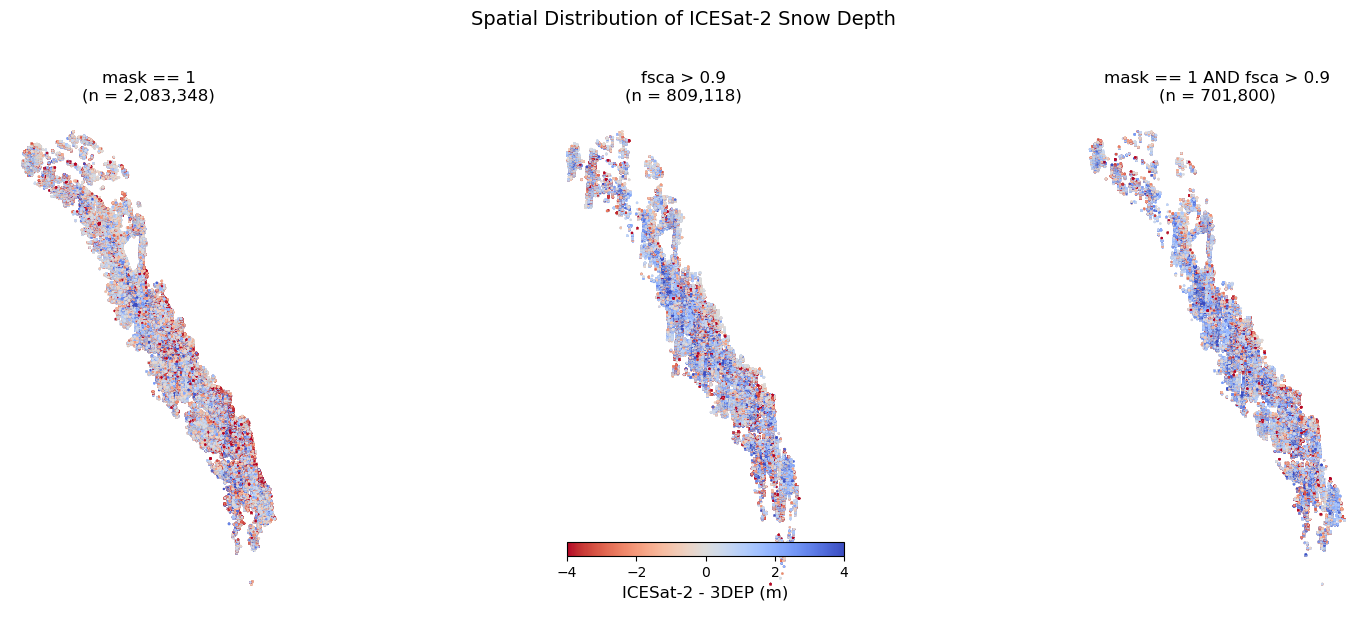

In [66]:
# Spatial plots of icesat2_3dep_dif with different filters
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Common plot settings
vmin, vmax = -4, 4
cmap = 'coolwarm_r'
markersize = 0.5

# Plot 1: mask == 1
ax = axes[0]
gdf_mask = atl06sr_gdf[atl06sr_gdf['mask'] == 1]
gdf_mask.plot(column='icesat2_3dep_dif', ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, 
              markersize=markersize, legend=False)
ax.set_title(f'mask == 1\n(n = {len(gdf_mask):,})', fontsize=12)
ax.set_axis_off()

# Plot 2: fsca > 0.9
ax = axes[1]
gdf_fsca = atl06sr_gdf[atl06sr_gdf['reanalysis_sca'] > 0.9]
gdf_fsca.plot(column='icesat2_3dep_dif', ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, 
              markersize=markersize, legend=False)
ax.set_title(f'fsca > 0.9\n(n = {len(gdf_fsca):,})', fontsize=12)
ax.set_axis_off()

# Plot 3: both
ax = axes[2]
gdf_both = atl06sr_gdf[(atl06sr_gdf['mask'] == 1) & (atl06sr_gdf['reanalysis_sca'] > 0.9)]
gdf_both.plot(column='icesat2_3dep_dif', ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, 
              markersize=markersize, legend=False)
ax.set_title(f'mask == 1 AND fsca > 0.9\n(n = {len(gdf_both):,})', fontsize=12)
ax.set_axis_off()

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.03, pad=0.05, shrink=0.6)
cbar.set_label('ICESat-2 - 3DEP (m)', fontsize=12)

plt.suptitle('Spatial Distribution of ICESat-2 Snow Depth', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [72]:
# Diagnostic: Compare fsca>0.9 vs fsca>0.9 AND mask==1
# What points are removed by adding mask==1?

# Define subsets
fsca_only = atl06sr_gdf[atl06sr_gdf['reanalysis_sca'] > 0.9]
both_filters = atl06sr_gdf[(atl06sr_gdf['reanalysis_sca'] > 0.9) & (atl06sr_gdf['mask'] == 1)]
removed_by_mask = atl06sr_gdf[(atl06sr_gdf['reanalysis_sca'] > 0.9) & (atl06sr_gdf['mask'] != 1)]

print("Sample sizes:")
print(f"  fsca > 0.9 only:           {len(fsca_only):,}")
print(f"  fsca > 0.9 AND mask == 1:  {len(both_filters):,}")
print(f"  Removed by adding mask:    {len(removed_by_mask):,} ({100*len(removed_by_mask)/len(fsca_only):.1f}%)")

print("\n" + "="*60)
print("Characteristics of REMOVED points (fsca>0.9 but mask!=1):")
print("="*60)

# Elevation distribution
print(f"\nElevation (3dep.value):")
print(f"  Removed:  mean={removed_by_mask['3dep.value'].mean():.0f}m, median={removed_by_mask['3dep.value'].median():.0f}m")
print(f"  Kept:     mean={both_filters['3dep.value'].mean():.0f}m, median={both_filters['3dep.value'].median():.0f}m")

# Slope distribution
print(f"\nSlope:")
print(f"  Removed:  mean={removed_by_mask['slope'].mean():.1f}°, median={removed_by_mask['slope'].median():.1f}°")
print(f"  Kept:     mean={both_filters['slope'].mean():.1f}°, median={both_filters['slope'].median():.1f}°")

# Snow depth (icesat2_3dep_dif) distribution  
print(f"\nICESat-2 snow depth (icesat2_3dep_dif):")
print(f"  Removed:  mean={removed_by_mask['icesat2_3dep_dif'].mean():.2f}m, median={removed_by_mask['icesat2_3dep_dif'].median():.2f}m")
print(f"  Kept:     mean={both_filters['icesat2_3dep_dif'].mean():.2f}m, median={both_filters['icesat2_3dep_dif'].median():.2f}m")

# Reanalysis SD distribution
print(f"\nReanalysis snow depth (reanalysis_sd):")
print(f"  Removed:  mean={removed_by_mask['reanalysis_sd'].mean():.2f}m, median={removed_by_mask['reanalysis_sd'].median():.2f}m")
print(f"  Kept:     mean={both_filters['reanalysis_sd'].mean():.2f}m, median={both_filters['reanalysis_sd'].median():.2f}m")

# Error (difference between IS2 and reanalysis)
removed_error = removed_by_mask['icesat2_3dep_dif'] - removed_by_mask['reanalysis_sd']
kept_error = both_filters['icesat2_3dep_dif'] - both_filters['reanalysis_sd']
print(f"\nIS2 - Reanalysis error (absolute):")
print(f"  Removed:  mean={removed_error.mean():.2f}m, median={removed_error.median():.2f}m, std={removed_error.std():.2f}m")
print(f"  Kept:     mean={kept_error.mean():.2f}m, median={kept_error.median():.2f}m, std={kept_error.std():.2f}m")

# Percent bias: (IS2 - reanalysis) / reanalysis * 100
# Only calculate where reanalysis > 0 to avoid division issues
removed_valid = removed_by_mask[removed_by_mask['reanalysis_sd'] > 0.1]  # threshold to avoid near-zero division
kept_valid = both_filters[both_filters['reanalysis_sd'] > 0.1]

removed_pct_bias = ((removed_valid['icesat2_3dep_dif'] - removed_valid['reanalysis_sd']) / removed_valid['reanalysis_sd']) * 100
kept_pct_bias = ((kept_valid['icesat2_3dep_dif'] - kept_valid['reanalysis_sd']) / kept_valid['reanalysis_sd']) * 100

print(f"\nPercent bias [(IS2 - Reanalysis) / Reanalysis * 100] (where reanalysis > 0.1m):")
print(f"  Removed:  mean={removed_pct_bias.mean():.1f}%, median={removed_pct_bias.median():.1f}%")
print(f"  Kept:     mean={kept_pct_bias.mean():.1f}%, median={kept_pct_bias.median():.1f}%")

# fsca distribution
print(f"\nReanalysis SCA:")
print(f"  Removed:  mean={removed_by_mask['reanalysis_sca'].mean():.3f}, median={removed_by_mask['reanalysis_sca'].median():.3f}")
print(f"  Kept:     mean={both_filters['reanalysis_sca'].mean():.3f}, median={both_filters['reanalysis_sca'].median():.3f}")

print("\n" + "="*60)
print("Note: mask==1 filters for 37-year avg April 1 FSCA >= 0.5")
print("This removes lower-elevation areas with less consistent snow cover.")

Sample sizes:
  fsca > 0.9 only:           809,118
  fsca > 0.9 AND mask == 1:  701,800
  Removed by adding mask:    107,318 (13.3%)

Characteristics of REMOVED points (fsca>0.9 but mask!=1):

Elevation (3dep.value):
  Removed:  mean=1921m, median=1932m
  Kept:     mean=2603m, median=2607m

Slope:
  Removed:  mean=15.3°, median=14.0°
  Kept:     mean=15.5°, median=14.0°

ICESat-2 snow depth (icesat2_3dep_dif):
  Removed:  mean=0.12m, median=0.29m
  Kept:     mean=0.64m, median=0.76m

Reanalysis snow depth (reanalysis_sd):
  Removed:  mean=0.45m, median=0.34m
  Kept:     mean=1.09m, median=0.88m

IS2 - Reanalysis error (absolute):
  Removed:  mean=-0.33m, median=-0.10m, std=2.04m
  Kept:     mean=-0.45m, median=-0.20m, std=2.11m

Percent bias [(IS2 - Reanalysis) / Reanalysis * 100] (where reanalysis > 0.1m):
  Removed:  mean=-107.1%, median=-21.0%
  Kept:     mean=-77.1%, median=-18.8%

Reanalysis SCA:
  Removed:  mean=0.970, median=0.982
  Kept:     mean=0.978, median=0.995

Note: mask

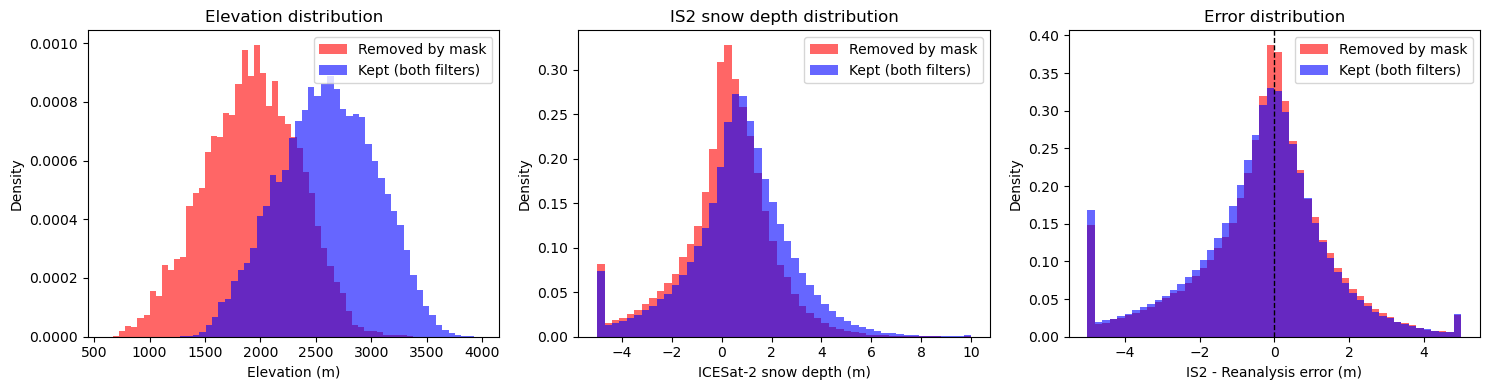


Mask values in the 'removed' subset:
mask
0    107318
Name: count, dtype: int64


In [70]:
# Visualize elevation distributions of kept vs removed points
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Elevation histogram
axes[0].hist(removed_by_mask['3dep.value'], bins=50, alpha=0.6, label='Removed by mask', color='red', density=True)
axes[0].hist(both_filters['3dep.value'], bins=50, alpha=0.6, label='Kept (both filters)', color='blue', density=True)
axes[0].set_xlabel('Elevation (m)')
axes[0].set_ylabel('Density')
axes[0].set_title('Elevation distribution')
axes[0].legend()

# IS2 snow depth histogram
axes[1].hist(removed_by_mask['icesat2_3dep_dif'].clip(-5, 10), bins=50, alpha=0.6, label='Removed by mask', color='red', density=True)
axes[1].hist(both_filters['icesat2_3dep_dif'].clip(-5, 10), bins=50, alpha=0.6, label='Kept (both filters)', color='blue', density=True)
axes[1].set_xlabel('ICESat-2 snow depth (m)')
axes[1].set_ylabel('Density')
axes[1].set_title('IS2 snow depth distribution')
axes[1].legend()

# Error (IS2 - reanalysis) histogram  
axes[2].hist(removed_error.clip(-5, 5), bins=50, alpha=0.6, label='Removed by mask', color='red', density=True)
axes[2].hist(kept_error.clip(-5, 5), bins=50, alpha=0.6, label='Kept (both filters)', color='blue', density=True)
axes[2].axvline(0, color='black', linestyle='--', lw=1)
axes[2].set_xlabel('IS2 - Reanalysis error (m)')
axes[2].set_ylabel('Density')
axes[2].set_title('Error distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

# What is mask filtering on? Check mask values for the removed points
print("\nMask values in the 'removed' subset:")
print(removed_by_mask['mask'].value_counts())

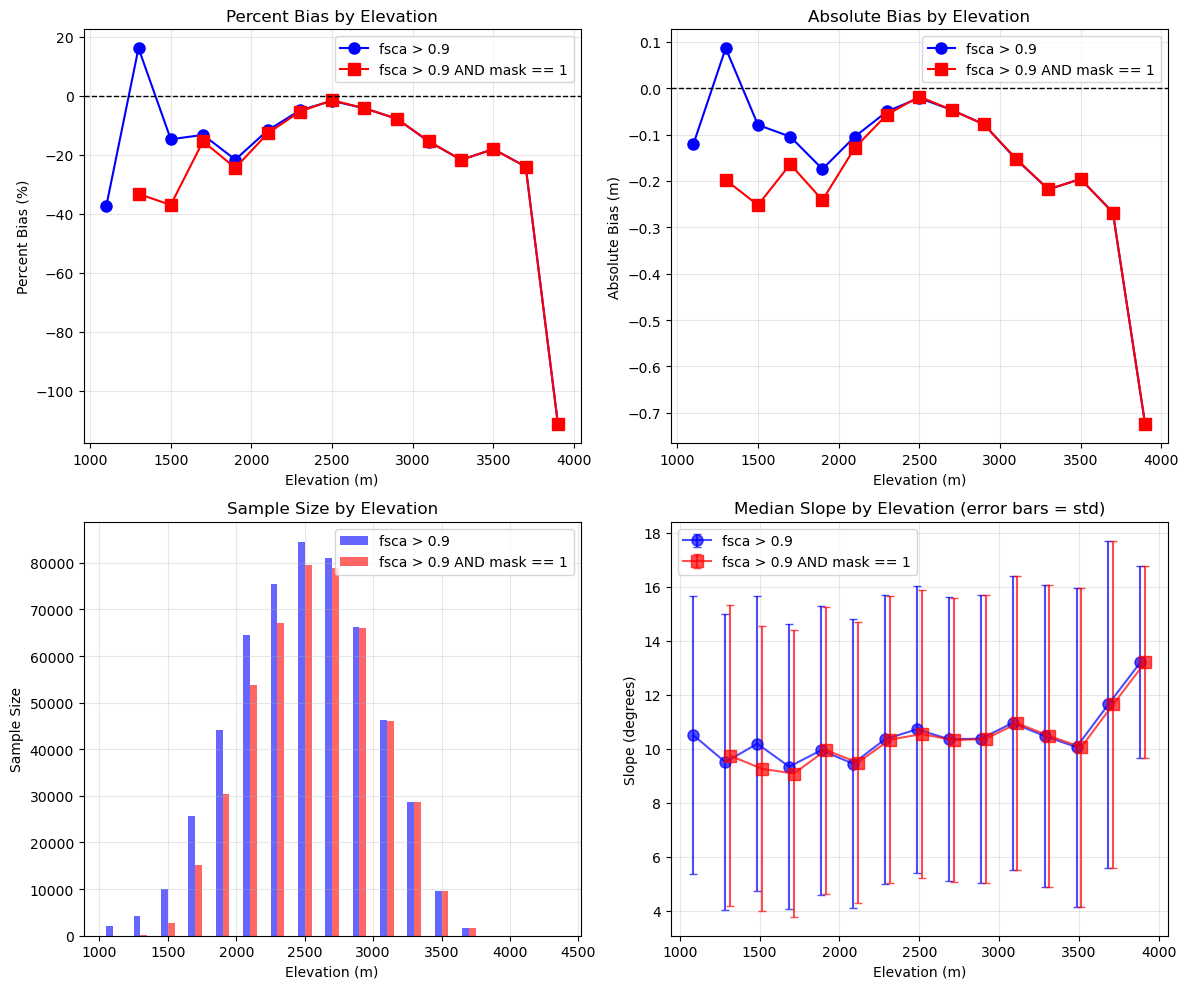


Percent Bias by Elevation Bin:
Elev (m)     fsca>0.9 pct_bias    both pct_bias        Difference     
--------------------------------------------------------------------------------
1100         N/A                  N/A                  N/A            
1300         16.1                 -33.3                -49.4          
1500         -14.8                -37.0                -22.3          
1700         -13.3                -15.4                -2.2           
1900         -21.7                -24.5                -2.8           
2100         -11.8                -12.8                -1.0           
2300         -5.0                 -5.4                 -0.4           
2500         -1.7                 -1.5                 0.2            
2700         -4.3                 -4.3                 0.0            
2900         -7.8                 -7.8                 -0.0           
3100         -15.6                -15.5                0.1            
3300         -21.8                -

In [86]:
# Analyze percent bias by elevation bin for each filter condition
# Compare fsca>0.9 vs fsca>0.9 AND mask==1
# Only include points with slope < 20 degrees
# No minimum sample size filter

def compute_pct_bias_by_elevation(df, filter_condition, elev_min, elev_max, 
                                   is2_col='icesat2_3dep_dif', reanalysis_col='reanalysis_sd',
                                   min_reanalysis=0.1, max_slope=20, min_samples=0):
    """Compute percent bias for each elevation bin."""
    filtered_df = df[filter_condition & (df['slope'] < max_slope)]
    
    results = []
    for e_min, e_max in zip(elev_min, elev_max):
        mask = (filtered_df['3dep.value'] > e_min) & (filtered_df['3dep.value'] < e_max)
        subset = filtered_df[mask]
        
        # Filter for valid reanalysis values
        valid = subset[subset[reanalysis_col] > min_reanalysis]
        
        if len(valid) >= min_samples and len(valid) > 0:
            pct_bias = ((valid[is2_col] - valid[reanalysis_col]) / valid[reanalysis_col] * 100).median()
            abs_bias = (valid[is2_col] - valid[reanalysis_col]).median()
            mean_is2 = valid[is2_col].median()
            mean_reanalysis = valid[reanalysis_col].median()
            n = len(valid)
        else:
            pct_bias = np.nan
            abs_bias = np.nan
            mean_is2 = np.nan
            mean_reanalysis = np.nan
            n = len(valid)
            
        results.append({
            'elev_bin': (e_min + e_max) / 2,
            'elev_max': e_max,
            'pct_bias': pct_bias,
            'abs_bias': abs_bias,
            'median_is2': mean_is2,
            'median_reanalysis': mean_reanalysis,
            'n': n
        })
    
    return pd.DataFrame(results)

# Compute for each filter (with slope < 20 filter applied, no min sample filter)
pct_bias_fsca = compute_pct_bias_by_elevation(atl06sr_gdf, filter_fsca, elev_min, elev_max)
pct_bias_both = compute_pct_bias_by_elevation(atl06sr_gdf, filter_both, elev_min, elev_max)

# Compute median slope by elevation for each filter (also with slope < 20, no min sample filter)
def compute_slope_by_elevation(df, filter_condition, elev_min, elev_max, max_slope=20, min_samples=0):
    """Compute median slope for each elevation bin."""
    filtered_df = df[filter_condition & (df['slope'] < max_slope)]
    results = []
    for e_min, e_max in zip(elev_min, elev_max):
        mask = (filtered_df['3dep.value'] > e_min) & (filtered_df['3dep.value'] < e_max)
        subset = filtered_df[mask]
        if len(subset) >= min_samples and len(subset) > 0:
            results.append({
                'elev_bin': (e_min + e_max) / 2,
                'median_slope': subset['slope'].median(),
                'mean_slope': subset['slope'].mean(),
                'std_slope': subset['slope'].std(),
                'n': len(subset)
            })
        else:
            results.append({
                'elev_bin': (e_min + e_max) / 2,
                'median_slope': np.nan,
                'mean_slope': np.nan,
                'std_slope': np.nan,
                'n': len(subset)
            })
    return pd.DataFrame(results)

slope_fsca = compute_slope_by_elevation(atl06sr_gdf, filter_fsca, elev_min, elev_max)
slope_both = compute_slope_by_elevation(atl06sr_gdf, filter_both, elev_min, elev_max)

# Plot comparison - now with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Percent bias by elevation
ax = axes[0, 0]
ax.plot(pct_bias_fsca['elev_bin'], pct_bias_fsca['pct_bias'], 'o-', label='fsca > 0.9', color='blue', markersize=8)
ax.plot(pct_bias_both['elev_bin'], pct_bias_both['pct_bias'], 's-', label='fsca > 0.9 AND mask == 1', color='red', markersize=8)
ax.axhline(0, color='black', linestyle='--', lw=1)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Percent Bias (%)')
ax.set_title('Percent Bias by Elevation')
ax.legend()
ax.grid(True, alpha=0.3)

# Absolute bias by elevation
ax = axes[0, 1]
ax.plot(pct_bias_fsca['elev_bin'], pct_bias_fsca['abs_bias'], 'o-', label='fsca > 0.9', color='blue', markersize=8)
ax.plot(pct_bias_both['elev_bin'], pct_bias_both['abs_bias'], 's-', label='fsca > 0.9 AND mask == 1', color='red', markersize=8)
ax.axhline(0, color='black', linestyle='--', lw=1)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Absolute Bias (m)')
ax.set_title('Absolute Bias by Elevation')
ax.legend()
ax.grid(True, alpha=0.3)

# Sample size by elevation
ax = axes[1, 0]
ax.bar(pct_bias_fsca['elev_bin'] - 25, pct_bias_fsca['n'], width=50, alpha=0.6, label='fsca > 0.9', color='blue')
ax.bar(pct_bias_both['elev_bin'] + 25, pct_bias_both['n'], width=50, alpha=0.6, label='fsca > 0.9 AND mask == 1', color='red')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Sample Size')
ax.set_title('Sample Size by Elevation')
ax.legend()
ax.grid(True, alpha=0.3)

# Median slope by elevation
ax = axes[1, 1]
ax.errorbar(slope_fsca['elev_bin'] - 15, slope_fsca['median_slope'], yerr=slope_fsca['std_slope'], 
            fmt='o-', label='fsca > 0.9', color='blue', markersize=8, capsize=3, alpha=0.7)
ax.errorbar(slope_both['elev_bin'] + 15, slope_both['median_slope'], yerr=slope_both['std_slope'], 
            fmt='s-', label='fsca > 0.9 AND mask == 1', color='red', markersize=8, capsize=3, alpha=0.7)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Slope (degrees)')
ax.set_title('Median Slope by Elevation (error bars = std)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison table
print("\nPercent Bias by Elevation Bin:")
print("="*80)
print(f"{'Elev (m)':<12} {'fsca>0.9 pct_bias':<20} {'both pct_bias':<20} {'Difference':<15}")
print("-"*80)
for i in range(len(pct_bias_fsca)):
    e = pct_bias_fsca.loc[i, 'elev_bin']
    fsca_pct = pct_bias_fsca.loc[i, 'pct_bias']
    both_pct = pct_bias_both.loc[i, 'pct_bias']
    diff = both_pct - fsca_pct if not (np.isnan(fsca_pct) or np.isnan(both_pct)) else np.nan
    print(f"{e:<12.0f} {fsca_pct:<20.1f} {both_pct:<20.1f} {diff:<15.1f}" if not np.isnan(diff) else f"{e:<12.0f} {'N/A':<20} {'N/A':<20} {'N/A':<15}")

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


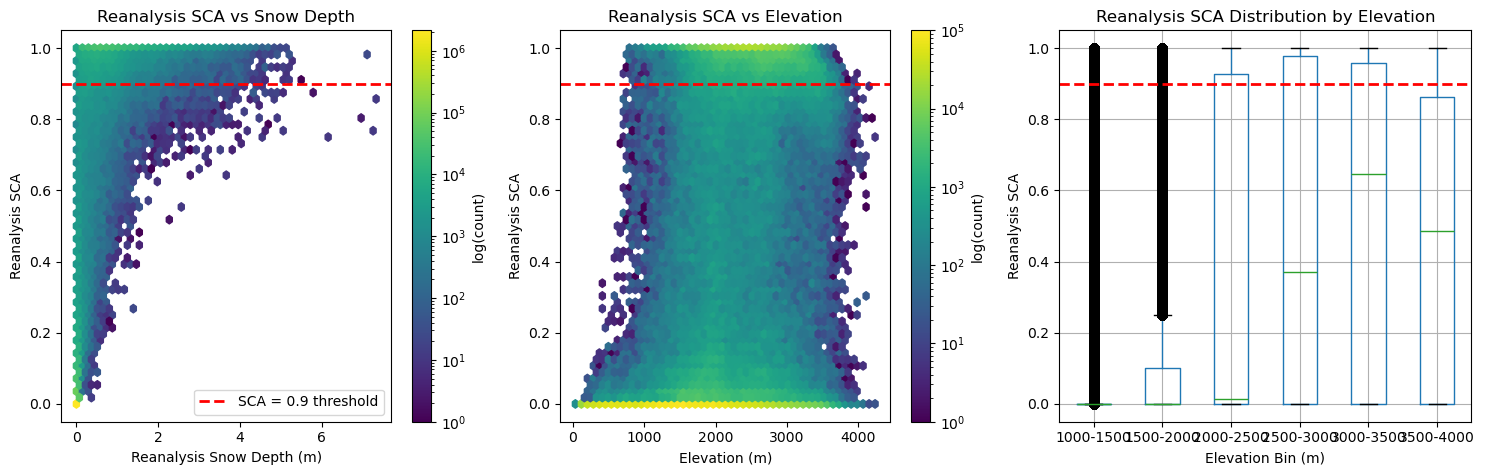


Reanalysis SCA summary by elevation bin (slope < 20):
              count   mean    std  min  25%    50%    75%  max
elev_bin                                                      
1000-1500  544784.0  0.044  0.172  0.0  0.0  0.000  0.000  1.0
1500-2000  757618.0  0.177  0.338  0.0  0.0  0.000  0.100  1.0
2000-2500  715897.0  0.352  0.437  0.0  0.0  0.013  0.928  1.0
2500-3000  513045.0  0.473  0.456  0.0  0.0  0.370  0.978  1.0
3000-3500  212086.0  0.497  0.452  0.0  0.0  0.645  0.957  1.0
3500-4000   28891.0  0.440  0.411  0.0  0.0  0.486  0.863  1.0


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6331/531064176.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_slope20.groupby('elev_bin')['reanalysis_sca'].describe().round(3))


In [88]:
# Plot distribution of reanalysis_sca vs reanalysis_sd and vs elevation
# Using slope < 20 filter

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Get filtered data
df_slope20 = atl06sr_gdf[atl06sr_gdf['slope'] < 20]

# 1. Scatter: reanalysis_sca vs reanalysis_sd (hexbin for density)
ax = axes[0]
hb = ax.hexbin(df_slope20['reanalysis_sd'], df_slope20['reanalysis_sca'], 
               gridsize=50, cmap='viridis', mincnt=1, bins='log')
ax.axhline(0.9, color='red', linestyle='--', lw=2, label='SCA = 0.9 threshold')
ax.set_xlabel('Reanalysis Snow Depth (m)')
ax.set_ylabel('Reanalysis SCA')
ax.set_title('Reanalysis SCA vs Snow Depth')
ax.legend(loc='lower right')
plt.colorbar(hb, ax=ax, label='log(count)')

# 2. Scatter: reanalysis_sca vs elevation (hexbin for density)
ax = axes[1]
hb = ax.hexbin(df_slope20['3dep.value'], df_slope20['reanalysis_sca'], 
               gridsize=50, cmap='viridis', mincnt=1, bins='log')
ax.axhline(0.9, color='red', linestyle='--', lw=2, label='SCA = 0.9 threshold')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Reanalysis SCA')
ax.set_title('Reanalysis SCA vs Elevation')
#ax.legend(loc='lower right')
plt.colorbar(hb, ax=ax, label='log(count)')

# 3. Box plot of SCA by elevation bin
ax = axes[2]
# Create elevation bins
df_slope20['elev_bin'] = pd.cut(df_slope20['3dep.value'], 
                                 bins=[1000, 1500, 2000, 2500, 3000, 3500, 4000],
                                 labels=['1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-3500', '3500-4000'])
df_slope20.boxplot(column='reanalysis_sca', by='elev_bin', ax=ax)
ax.axhline(0.9, color='red', linestyle='--', lw=2, label='SCA = 0.9')
ax.set_xlabel('Elevation Bin (m)')
ax.set_ylabel('Reanalysis SCA')
ax.set_title('Reanalysis SCA Distribution by Elevation')
plt.suptitle('')  # Remove automatic title
#ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Print summary stats
print("\nReanalysis SCA summary by elevation bin (slope < 20):")
print("="*70)
print(df_slope20.groupby('elev_bin')['reanalysis_sca'].describe().round(3))

### Create dataframe of metrics for plotting:

In [20]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask'],
      dtype='object')

In [ ]:
# all slopes:

x_medians1 = []
subset_labels1 = []
elev1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf_cleaned.loc[(atl06sr_gdf_cleaned['reanalysis_sca']>0.9) & (atl06sr_gdf_cleaned['h_mean']>x_min) & (atl06sr_gdf_cleaned['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians1.append(np.nanmedian(subset))
        subset_labels1.append('all_by_elevation')
    else:
        x_medians1.append(np.nan)
        subset_labels1.append('all_by_elevation')

y_medians1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:
        y_medians1.append(np.nanmedian(subset))
    else:
        y_medians1.append(np.nan)

# md_1 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_1.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# under 20 slope:
x_medians2 = []
subset_labels2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf_cleaned.loc[(atl06sr_gdf_cleaned['reanalysis_sca']>0.9) & (atl06sr_gdf_cleaned['slope']<20) & (atl06sr_gdf_cleaned['h_mean']>x_min) & (atl06sr_gdf_cleaned['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians2.append(np.nanmedian(subset))
        subset_labels2.append('under_20slope')
    else:
        x_medians2.append(np.nan)
        subset_labels2.append('under_20slope')

y_medians2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:    
        y_medians2.append(np.nanmedian(subset))
    else:
        y_medians2.append(np.nan)

# md_2 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# by slope:
x_medians3 = []
subset_labels3 = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians3.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))
    subset_labels3.append('median_by_slope')

y_medians3 = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians3.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

residuals3 = []
residuals_n = []
residuals_labels3 = []
for x_min, x_max in zip(slope_min, slope_max):
    subset_is2 = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values
    subset_r = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values
    
    residuals3.append(np.nanmedian(subset_is2) - np.nanmedian(subset_r))
    residuals_n.append(len(subset_is2))
    residuals_labels3.append('residuals_by_slope')


In [ ]:
elev_max_list = elev_max.tolist()

scatter_data = pd.DataFrame({
    'x_medians': x_medians1 + x_medians2,
    'y_medians': y_medians1 + y_medians2,
    'labels': subset_labels1 + subset_labels2,
    'elevation_bin': elev_max_list + elev_max_list
})

In [ ]:
residual_data = pd.DataFrame({
    'residuals': residuals3,
    'sample_size': residuals_n,
    'slope_bin': slope_max,
    'labels': residuals_labels3,
    'y_pos': [0.2, 0.2,0.2,0.2,0.2,0.2,0.2] #[1.6,1.3,1,0.7,0.4,0.1,-0.2]
})

residual_data['sign'] = np.where(residual_data['residuals'] >= 0, 'positive', 'negative')
residual_data['annotation'] = residual_data['residuals'].round(2).astype(str)
residual_data['sample_size_annotation'] = residual_data['sample_size'].astype(str)

In [ ]:
all_bias = np.mean(scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'] - 
                   scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'])

slope_bias = np.mean(scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'] -
                     scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'])

all_cor = np.corrcoef(scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'].dropna(),
                        scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'].dropna())[0,1]

slope_cor = np.corrcoef(scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'].dropna(),
                        scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'].dropna())[0,1]

all_rmse = np.sqrt(np.nanmean((scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'] -
                                    scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'])**2))
slope_rmse = np.sqrt(np.nanmean((scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'] -
                                    scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'])**2))

all_ubrmse = np.sqrt(all_rmse**2 - all_bias**2)
slope_ubrmse = np.sqrt(slope_rmse**2 - slope_bias**2)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 14 and the array at index 1 has size 15

In [ ]:
# does not include unbiased rmse

metrics_data = pd.DataFrame({
    'metric': [all_bias, slope_bias, all_cor, slope_cor, all_rmse, slope_rmse],
    'metric_label':['bias', 'bias', 'correlation', 'correlation', 'rmse', 'rmse'],
    'labels': ['all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope'],
    'x_pos': [0.8, 0.8, 0.8, 0.8, 0.8, 0.8],
    'y_pos': [0.2, 0.2, 0.12, 0.12, 0.04, 0.04]  #[-0.01,-0.01,-0.08, -0.08, -0.15, -0.15, -0.22, -0.22]
})

metrics_data['metric_2f'] = metrics_data['metric'].round(2)

### Plot scatters and bar plots by elevation and slope:

In [ ]:
import matplotlib as mpl
cmap = mpl.colormaps['managua'].resampled(256)
colors = [mpl.colors.rgb2hex(cmap(i/(256-1))) for i in range(256)]


### Plot using fsca > 0.9

In [ ]:
x = np.linspace(0, 1.4, 100) # Creates 100 points between x_min and x_max
y = x
line_data = pd.DataFrame({
    'x': [-0.2, 1.4],
    'y': [-0.2, 1.4]
})

scatter_chart = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='all_by_elevation']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
    y=alt.Y('y_medians:Q', title='Sampled Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
    color=alt.Color('elevation_bin:Q', title='Elevation (m)', scale=alt.Scale(range=colors)) # , legend=None
).properties( 
    title='All slopes'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_data[metrics_data['labels']=='all_by_elevation']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_slope = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='under_20slope']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
    y=alt.Y('y_medians:Q', title='Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
    color=alt.Color('elevation_bin:Q', scale=alt.Scale(range=colors))
    # .legend(orient="none", # Hide default legend position
    #     legendX=600,    # X position in pixels from left
    #     legendY=75)
).properties(
    title='' #Only slopes under 20 degrees
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
)+ \
    alt.Chart(metrics_data[metrics_data['labels']=='under_20slope']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )

residuals_chart = alt.Chart(residual_data).mark_bar(color = '#E7969C').encode(
    x=alt.X('slope_bin:O', title='Slope Bin (degrees)'),
    y=alt.Y('residuals:Q', title='Residuals (m)', scale=alt.Scale(domain=[-10.25,1.])),
    #color=alt.Color('sign:N', legend=None, scale=alt.Scale(domain=['negative', 'positive'], range=['#8D0051', '#E9AC5B']))
).properties(
    width=200
) + \
    alt.Chart(residual_data).mark_text(
        align='center', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=25,fontSize=15).encode(
        x='slope_bin:O', y='residuals:Q', text='annotation:Q'
        ) + \
    alt.Chart(residual_data).mark_text(
        align='right', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=0,fontSize=15).encode(
        x='slope_bin:O', y='y_pos:Q', text='sample_size_annotation:Q'
        )

combined_2_charts = alt.hconcat(scatter_chart, scatter_chart_slope)


combined = alt.hconcat(combined_2_charts, residuals_chart).configure_axis(
    grid=False,  # This removes the grid lines
    labelFontSize=14,  # Set default label font size
    titleFontSize=16   # Set default title font size
) 
combined


alt.HConcatChart(...)

### do the same calcs but using the snow mask instead of fsca>0.9

In [27]:
# all slopes:

x_medians1 = []
subset_labels1 = []
elev1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians1.append(np.nanmedian(subset))
        subset_labels1.append('all_by_elevation')
    else:
        x_medians1.append(np.nan)
        subset_labels1.append('all_by_elevation')

y_medians1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:
        y_medians1.append(np.nanmedian(subset))
    else:
        y_medians1.append(np.nan)

# md_1 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_1.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# under 20 slope:
x_medians2 = []
subset_labels2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians2.append(np.nanmedian(subset))
        subset_labels2.append('under_20slope')
    else:
        x_medians2.append(np.nan)
        subset_labels2.append('under_20slope')

y_medians2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:    
        y_medians2.append(np.nanmedian(subset))
    else:
        y_medians2.append(np.nan)

# md_2 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# by slope:
residuals3 = []
residuals_n = []
residuals_labels3 = []
for x_min, x_max in zip(slope_min, slope_max):
    subset_is2 = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values
    subset_r = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values
    
    residuals3.append(np.nanmedian(subset_is2) - np.nanmedian(subset_r))
    residuals_n.append(len(subset_is2))
    residuals_labels3.append('residuals_by_slope')


In [ ]:
elev_max_list = elev_max.tolist()

scatter_data = pd.DataFrame({
    'x_medians': x_medians1 + x_medians2,
    'y_medians': y_medians1 + y_medians2,
    'labels': subset_labels1 + subset_labels2,
    'elevation_bin': elev_max_list + elev_max_list
})

In [ ]:
residual_data = pd.DataFrame({
    'residuals': residuals3,
    'sample_size': residuals_n,
    'slope_bin': slope_max,
    'labels': residuals_labels3,
    'y_pos': [0.2, 0.2,0.2,0.2,0.2,0.2,0.2] #[1.6,1.3,1,0.7,0.4,0.1,-0.2]
})

residual_data['sign'] = np.where(residual_data['residuals'] >= 0, 'positive', 'negative')
residual_data['annotation'] = residual_data['residuals'].round(2).astype(str)
residual_data['sample_size_annotation'] = residual_data['sample_size'].astype(str)

In [ ]:
all_bias = np.mean(scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'] - 
                   scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'])

slope_bias = np.mean(scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'] -
                     scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'])

all_cor = np.corrcoef(scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'].dropna(),
                        scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'].dropna())[0,1]

slope_cor = np.corrcoef(scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'].dropna(),
                        scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'].dropna())[0,1]

all_rmse = np.sqrt(np.nanmean((scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'] -
                                    scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'])**2))
slope_rmse = np.sqrt(np.nanmean((scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'] -
                                    scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'])**2))

all_ubrmse = np.sqrt(all_rmse**2 - all_bias**2)
slope_ubrmse = np.sqrt(slope_rmse**2 - slope_bias**2)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 14 and the array at index 1 has size 15

In [ ]:
# includes unbiased rmse

# metrics_data = pd.DataFrame({
#     'metric': [all_bias, slope_bias, all_cor, slope_cor, all_rmse, slope_rmse, all_ubrmse, slope_ubrmse],
#     'metric_label':['bias', 'bias', 'correlation', 'correlation', 'rmse', 'rmse', 'ubrmse', 'ubrmse'],
#     'labels': ['all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope'],
#     'x_pos': [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
#     'y_pos': [0.2, 0.2, 0.12, 0.12, 0.04, 0.04, -0.06, -0.06]  #[-0.01,-0.01,-0.08, -0.08, -0.15, -0.15, -0.22, -0.22]
# })

# metrics_data['metric_2f'] = metrics_data['metric'].round(2)

In [ ]:
# does not include unbiased rmse

metrics_data = pd.DataFrame({
    'metric': [all_bias, slope_bias, all_cor, slope_cor, all_rmse, slope_rmse],
    'metric_label':['bias', 'bias', 'correlation', 'correlation', 'rmse', 'rmse'],
    'labels': ['all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope'],
    'x_pos': [0.8, 0.8, 0.8, 0.8, 0.8, 0.8],
    'y_pos': [0.2, 0.2, 0.12, 0.12, 0.04, 0.04]  #[-0.01,-0.01,-0.08, -0.08, -0.15, -0.15, -0.22, -0.22]
})

metrics_data['metric_2f'] = metrics_data['metric'].round(2)

### Plot using 1 april mean fsca > 0.5

In [ ]:
x = np.linspace(0, 1.4, 100) # Creates 100 points between x_min and x_max
y = x
line_data = pd.DataFrame({
    'x': [0, 1.4],
    'y': [0, 1.4]
})

scatter_chart = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='all_by_elevation']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[0, 1.4])),
    y=alt.Y('y_medians:Q', title='Sampled Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[0, 1.4])),
    color=alt.Color('elevation_bin:Q', title='Elevation (m)', scale=alt.Scale(range=colors)) # , legend=None
).properties( 
    title='All slopes'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_data[metrics_data['labels']=='all_by_elevation']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_slope = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='under_20slope']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[0, 1.4])),
    y=alt.Y('y_medians:Q', title='Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[0, 1.4])),
    color=alt.Color('elevation_bin:Q', scale=alt.Scale(range=colors))
    # .legend(orient="none", # Hide default legend position
    #     legendX=600,    # X position in pixels from left
    #     legendY=75)
).properties(
    title='' #Only slopes under 20 degrees
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
)+ \
    alt.Chart(metrics_data[metrics_data['labels']=='under_20slope']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )

residuals_chart = alt.Chart(residual_data).mark_bar(color = '#E7969C').encode(
    x=alt.X('slope_bin:O', title='Slope Bin (degrees)'),
    y=alt.Y('residuals:Q', title='Residuals (m)', scale=alt.Scale(domain=[-10.25,1.])),
    #color=alt.Color('sign:N', legend=None, scale=alt.Scale(domain=['negative', 'positive'], range=['#8D0051', '#E9AC5B']))
).properties(
    width=200
) + \
    alt.Chart(residual_data).mark_text(
        align='center', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=25,fontSize=15).encode(
        x='slope_bin:O', y='residuals:Q', text='annotation:Q'
        ) + \
    alt.Chart(residual_data).mark_text(
        align='right', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=0,fontSize=15).encode(
        x='slope_bin:O', y='y_pos:Q', text='sample_size_annotation:Q'
        )

combined_2_charts = alt.hconcat(scatter_chart, scatter_chart_slope)


combined = alt.hconcat(combined_2_charts, residuals_chart).configure_axis(
    grid=False,  # This removes the grid lines
    labelFontSize=14,  # Set default label font size
    titleFontSize=16   # Set default title font size
) 
combined


alt.HConcatChart(...)

### Same calcs but for both 0.5 mask and fsca>0.9

In [34]:
# all slopes:

x_medians1 = []
subset_labels1 = []
elev1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians1.append(np.nanmedian(subset))
        subset_labels1.append('all_by_elevation')
    else:
        x_medians1.append(np.nan)
        subset_labels1.append('all_by_elevation')

y_medians1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:
        y_medians1.append(np.nanmedian(subset))
    else:
        y_medians1.append(np.nan)

# md_1 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_1.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# under 20 slope:
x_medians2 = []
subset_labels2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians2.append(np.nanmedian(subset))
        subset_labels2.append('under_20slope')
    else:
        x_medians2.append(np.nan)
        subset_labels2.append('under_20slope')

y_medians2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:    
        y_medians2.append(np.nanmedian(subset))
    else:
        y_medians2.append(np.nan)

# md_2 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# by slope:
residuals3 = []
residuals_n = []
residuals_labels3 = []
for x_min, x_max in zip(slope_min, slope_max):
    subset_is2 = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values
    subset_r = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values
    
    residuals3.append(np.nanmedian(subset_is2) - np.nanmedian(subset_r))
    residuals_n.append(len(subset_is2))
    residuals_labels3.append('residuals_by_slope')


In [35]:
elev_max_list = elev_max.tolist()

scatter_data = pd.DataFrame({
    'x_medians': x_medians1 + x_medians2,
    'y_medians': y_medians1 + y_medians2,
    'labels': subset_labels1 + subset_labels2,
    'elevation_bin': elev_max_list + elev_max_list
})

In [39]:
scatter_data

,x_medians,y_medians,labels,elevation_bin
0,NaN,NaN,all_by_elevation,1200
1,-0.227991,0.0064,all_by_elevation,1400
2,0.248969,0.0000,all_by_elevation,1600
3,0.638919,0.0000,all_by_elevation,1800
4,0.609042,0.0004,all_by_elevation,2000
5,0.697354,0.0069,all_by_elevation,2200
6,0.822107,0.0386,all_by_elevation,2400
7,0.892745,0.0778,all_by_elevation,2600
8,0.821598,0.1466,all_by_elevation,2800
9,0.733676,0.2130,all_by_elevation,3000


In [36]:
residual_data = pd.DataFrame({
    'residuals': residuals3,
    'sample_size': residuals_n,
    'slope_bin': slope_max,
    'labels': residuals_labels3,
    'y_pos': [0.2, 0.2,0.2,0.2,0.2,0.2,0.2] #[1.6,1.3,1,0.7,0.4,0.1,-0.2]
})

residual_data['sign'] = np.where(residual_data['residuals'] >= 0, 'positive', 'negative')
residual_data['annotation'] = residual_data['residuals'].round(2).astype(str)
residual_data['sample_size_annotation'] = residual_data['sample_size'].astype(str)

In [37]:
all_bias = np.mean(scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'] - 
                   scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'])

slope_bias = np.mean(scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'] -
                     scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'])

all_cor = np.corrcoef(scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'].dropna(),
                        scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'].dropna())[0,1]

slope_cor = np.corrcoef(scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'].dropna(),
                        scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'].dropna())[0,1]

all_rmse = np.sqrt(np.nanmean((scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'] -
                                    scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'])**2))
slope_rmse = np.sqrt(np.nanmean((scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'] -
                                    scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'])**2))

all_ubrmse = np.sqrt(all_rmse**2 - all_bias**2)
slope_ubrmse = np.sqrt(slope_rmse**2 - slope_bias**2)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 14 and the array at index 1 has size 15

In [176]:
# includes unbiased rmse

# metrics_data = pd.DataFrame({
#     'metric': [all_bias, slope_bias, all_cor, slope_cor, all_rmse, slope_rmse, all_ubrmse, slope_ubrmse],
#     'metric_label':['bias', 'bias', 'correlation', 'correlation', 'rmse', 'rmse', 'ubrmse', 'ubrmse'],
#     'labels': ['all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope'],
#     'x_pos': [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
#     'y_pos': [0.2, 0.2, 0.12, 0.12, 0.04, 0.04, -0.06, -0.06]  #[-0.01,-0.01,-0.08, -0.08, -0.15, -0.15, -0.22, -0.22]
# })

# metrics_data['metric_2f'] = metrics_data['metric'].round(2)

In [31]:
# does not include unbiased rmse

metrics_data = pd.DataFrame({
    'metric': [all_bias, slope_bias, all_cor, slope_cor, all_rmse, slope_rmse],
    'metric_label':['bias', 'bias', 'correlation', 'correlation', 'rmse', 'rmse'],
    'labels': ['all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope'],
    'x_pos': [0.8, 0.8, 0.8, 0.8, 0.8, 0.8],
    'y_pos': [0.2, 0.2, 0.12, 0.12, 0.04, 0.04]  #[-0.01,-0.01,-0.08, -0.08, -0.15, -0.15, -0.22, -0.22]
})

metrics_data['metric_2f'] = metrics_data['metric'].round(2)

### plot using both:

In [ ]:
x = np.linspace(0, 1.4, 100) # Creates 100 points between x_min and x_max
y = x
line_data = pd.DataFrame({
    'x': [0, 1.4],
    'y': [0, 1.4]
})

scatter_chart = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='all_by_elevation']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[0, 1.4])),
    y=alt.Y('y_medians:Q', title='Sampled Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[0, 1.4])),
    color=alt.Color('elevation_bin:Q', title='Elevation (m)', scale=alt.Scale(range=colors)) # , legend=None
).properties( 
    title='All slopes'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_data[metrics_data['labels']=='all_by_elevation']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_slope = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='under_20slope']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[0, 1.4])),
    y=alt.Y('y_medians:Q', title='Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[0, 1.4])),
    color=alt.Color('elevation_bin:Q', scale=alt.Scale(range=colors))
    # .legend(orient="none", # Hide default legend position
    #     legendX=600,    # X position in pixels from left
    #     legendY=75)
).properties(
    title='' #Only slopes under 20 degrees
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
)+ \
    alt.Chart(metrics_data[metrics_data['labels']=='under_20slope']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )

residuals_chart = alt.Chart(residual_data).mark_bar(color = '#E7969C').encode(
    x=alt.X('slope_bin:O', title='Slope Bin (degrees)'),
    y=alt.Y('residuals:Q', title='Residuals (m)', scale=alt.Scale(domain=[-10.25,1.])),
    #color=alt.Color('sign:N', legend=None, scale=alt.Scale(domain=['negative', 'positive'], range=['#8D0051', '#E9AC5B']))
).properties(
    width=200
) + \
    alt.Chart(residual_data).mark_text(
        align='center', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=25,fontSize=15).encode(
        x='slope_bin:O', y='residuals:Q', text='annotation:Q'
        ) + \
    alt.Chart(residual_data).mark_text(
        align='right', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=0,fontSize=15).encode(
        x='slope_bin:O', y='y_pos:Q', text='sample_size_annotation:Q'
        )

combined_2_charts = alt.hconcat(scatter_chart, scatter_chart_slope)


combined = alt.hconcat(combined_2_charts, residuals_chart).configure_axis(
    grid=False,  # This removes the grid lines
    labelFontSize=14,  # Set default label font size
    titleFontSize=16   # Set default title font size
) 
combined


alt.HConcatChart(...)

In [56]:
combined.save('../../figures/scatter_by_elevation_n.png', dpi=500)

In [187]:
scatter_chart_slope.configure_axis(
    grid=False,  # This removes the grid lines
    labelFontSize=14,  # Set default label font size
    titleFontSize=16   # Set default title font size
) 

alt.LayerChart(...)

In [188]:
scatter_chart_slope.save('../../figures/scatter_by_elevation.png', dpi=500)

In [180]:
# same plot as above but using mask==1 instead of reanalysis_sca>0.9

x = np.linspace(0, 1.4, 100) # Creates 100 points between x_min and x_max
y = x
line_data = pd.DataFrame({
    'x': [-0.2, 1.4],
    'y': [-0.2, 1.4]
})

scatter_chart = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='all_by_elevation']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
    y=alt.Y('y_medians:Q', title='Sampled Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
    color=alt.Color('elevation_bin:Q', title='Elevation (m)', scale=alt.Scale(range=colors))
).properties(
    title='All slopes'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_data[metrics_data['labels']=='all_by_elevation']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_slope = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='under_20slope']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
    y=alt.Y('y_medians:Q', title='Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
    color=alt.Color('elevation_bin:Q', scale=alt.Scale(range=colors))
    # .legend(orient="none", # Hide default legend position
    #     legendX=600,    # X position in pixels from left
    #     legendY=75)
).properties(
    title='Only slopes under 20 degrees'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
)+ \
    alt.Chart(metrics_data[metrics_data['labels']=='under_20slope']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )

residuals_chart = alt.Chart(residual_data).mark_bar(color = '#E7969C').encode(
    x=alt.X('slope_bin:O', title='Slope Bin (degrees)'),
    y=alt.Y('residuals:Q', title='Residuals (m)', scale=alt.Scale(domain=[-10.25,1.])),
    #color=alt.Color('sign:N', legend=None, scale=alt.Scale(domain=['negative', 'positive'], range=['#8D0051', '#E9AC5B']))
).properties(
    width=200
) + \
    alt.Chart(residual_data).mark_text(
        align='center', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=25,fontSize=15).encode(
        x='slope_bin:O', y='residuals:Q', text='annotation:Q'
        ) + \
    alt.Chart(residual_data).mark_text(
        align='right', angle=90, color='black',baseline='bottom', dy=7, dx=0,fontSize=15).encode(
        x='slope_bin:O', y='y_pos:Q', text='sample_size_annotation:Q'
        )

combined_2_charts = alt.hconcat(scatter_chart, scatter_chart_slope)


combined = alt.hconcat(combined_2_charts, residuals_chart).configure_axis(
    grid=False,  # This removes the grid lines
    labelFontSize=14,  # Set default label font size
    titleFontSize=16   # Set default title font size
) 
combined

alt.HConcatChart(...)

### Plot a scatter of median is2 and reanalysis by date:

In [26]:
atl06sr_gdf_fsca_9 = atl06sr_gdf[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20)]
atl06sr_gdf_fsca_9['n'] = atl06sr_gdf_fsca_9.groupby('acqdate')['acqdate'].transform('count')

In [119]:
atl06sr_gdf_fsca_9['offset_sd'] = atl06sr_gdf_fsca_9['icesat2_3dep_dif'] - atl06sr_gdf_fsca_9['reanalysis_sd']

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [147]:
atl06sr_gdf_fsca_9.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask', 'n'],
      dtype='object')

In [148]:
medians_is2 = atl06sr_gdf_fsca_9[['icesat2_3dep_dif', 'acqdate','n', 'offset_sd', 'dowy']].dropna().groupby('acqdate').median()
medians_r = atl06sr_gdf_fsca_9[['reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').median()

medians_bydate = medians_is2.merge(medians_r, left_index=True, right_index=True, suffixes=('_is2', '_reanalysis'))
medians_bydate['offset_sd_abs'] = medians_bydate['offset_sd'].abs()


In [149]:
means_is2 = atl06sr_gdf_fsca_9[['icesat2_3dep_dif', 'acqdate','n', 'offset_sd', 'dowy']].dropna().groupby('acqdate').mean()
means_r = atl06sr_gdf_fsca_9[['reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').mean()

means_bydate = means_is2.merge(means_r, left_index=True, right_index=True, suffixes=('_is2', '_reanalysis'))
means_bydate['offset_sd_abs'] = means_bydate['offset_sd'].abs()


In [121]:
medians_bydate

,icesat2_3dep_dif,n,offset_sd,reanalysis_sd
acqdate,,,,
2018-12-03,0.313580,9551.0,0.029520,0.3020
2018-12-07,0.507532,7902.0,-0.039565,0.5556
2018-12-11,0.449129,13618.0,0.039375,0.4348
2018-12-12,0.441805,8327.0,0.031774,0.4260
2018-12-15,-0.112512,947.0,-0.230721,0.1294
...,...,...,...,...
2021-05-04,1.351012,34.0,0.434432,0.7996
2021-05-06,0.124651,131.0,-0.567053,0.6292
2021-05-08,0.887158,108.0,0.018252,0.9698


In [63]:
medians_is2 = atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>100),['icesat2_3dep_dif', 'acqdate','n']].dropna().groupby('acqdate').median()
medians_r = atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>100),['reanalysis_sd', 'acqdate','n']].dropna().groupby('acqdate').median()

medians_bydate_100 = medians_is2.merge(medians_r, left_index=True, right_index=True, suffixes=('_is2', '_reanalysis'))



In [115]:
medians_bydate_100

,icesat2_3dep_dif,n_is2,reanalysis_sd,n_reanalysis
acqdate,,,,
2018-12-03,0.313580,9551.0,0.3020,9551.0
2018-12-07,0.507532,7902.0,0.5556,7902.0
2018-12-11,0.449129,13618.0,0.4348,13618.0
2018-12-12,0.441805,8327.0,0.4260,8327.0
2018-12-15,-0.112512,947.0,0.1294,947.0
...,...,...,...,...
2021-04-13,0.882264,525.0,0.8754,525.0
2021-04-17,1.064047,382.0,1.0496,382.0
2021-05-06,0.124651,131.0,0.6292,131.0


In [64]:
medians_is2 = atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>300),['icesat2_3dep_dif', 'acqdate','n']].dropna().groupby('acqdate').median()
medians_r = atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>300),['reanalysis_sd', 'acqdate','n']].dropna().groupby('acqdate').median()

medians_bydate_300 = medians_is2.merge(medians_r, left_index=True, right_index=True, suffixes=('_is2', '_reanalysis'))

In [116]:
medians_bydate_300

,icesat2_3dep_dif,n_is2,reanalysis_sd,n_reanalysis
acqdate,,,,
2018-12-03,0.313580,9551.0,0.3020,9551.0
2018-12-07,0.507532,7902.0,0.5556,7902.0
2018-12-11,0.449129,13618.0,0.4348,13618.0
2018-12-12,0.441805,8327.0,0.4260,8327.0
2018-12-15,-0.112512,947.0,0.1294,947.0
...,...,...,...,...
2021-04-07,0.571352,5689.0,0.9988,5689.0
2021-04-11,0.848309,7043.0,1.0354,7043.0
2021-04-13,0.882264,525.0,0.8754,525.0


In [62]:
medians_is2 = atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>500),['icesat2_3dep_dif', 'acqdate','n']].dropna().groupby('acqdate').median()
medians_r = atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>500),['reanalysis_sd', 'acqdate','n']].dropna().groupby('acqdate').median()

medians_bydate_500 = medians_is2.merge(medians_r, left_index=True, right_index=True, suffixes=('_is2', '_reanalysis'))

In [117]:
medians_bydate_500

,icesat2_3dep_dif,n_is2,reanalysis_sd,n_reanalysis
acqdate,,,,
2018-12-03,0.313580,9551.0,0.3020,9551.0
2018-12-07,0.507532,7902.0,0.5556,7902.0
2018-12-11,0.449129,13618.0,0.4348,13618.0
2018-12-12,0.441805,8327.0,0.4260,8327.0
2018-12-15,-0.112512,947.0,0.1294,947.0
...,...,...,...,...
2021-04-01,0.810638,1614.0,0.8584,1614.0
2021-04-05,0.830014,804.0,1.0308,804.0
2021-04-07,0.571352,5689.0,0.9988,5689.0


In [84]:
bias_0 = np.mean(medians_bydate['icesat2_3dep_dif'] - 
                   medians_bydate['reanalysis_sd'])

bias_100 = np.mean(medians_bydate_100['icesat2_3dep_dif'] - 
                   medians_bydate_100['reanalysis_sd'])

bias_300 = np.mean(medians_bydate_300['icesat2_3dep_dif'] - 
                   medians_bydate_300['reanalysis_sd'])

bias_500 = np.mean(medians_bydate_500['icesat2_3dep_dif'] - 
                   medians_bydate_500['reanalysis_sd'])

cor_0 = np.corrcoef(medians_bydate['icesat2_3dep_dif'].dropna(),
                        medians_bydate['reanalysis_sd'].dropna())[0,1]

cor_100 = np.corrcoef(medians_bydate_100['icesat2_3dep_dif'].dropna(),
                        medians_bydate_100['reanalysis_sd'].dropna())[0,1]

cor_300 = np.corrcoef(medians_bydate_300['icesat2_3dep_dif'].dropna(),
                        medians_bydate_300['reanalysis_sd'].dropna())[0,1]

cor_500 = np.corrcoef(medians_bydate_500['icesat2_3dep_dif'].dropna(),
                        medians_bydate_500['reanalysis_sd'].dropna())[0,1]

rmse_0 = np.sqrt(np.nanmean((medians_bydate['icesat2_3dep_dif'] -
                                    medians_bydate['reanalysis_sd'])**2))
rmse_100 = np.sqrt(np.nanmean((medians_bydate_100['icesat2_3dep_dif'] -
                                    medians_bydate_100['reanalysis_sd'])**2))
rmse_300 = np.sqrt(np.nanmean((medians_bydate_300['icesat2_3dep_dif'] -
                                    medians_bydate_300['reanalysis_sd'])**2))
rmse_500 = np.sqrt(np.nanmean((medians_bydate_500['icesat2_3dep_dif'] -
                                    medians_bydate_500['reanalysis_sd'])**2))

ubrmse_0 = np.sqrt(rmse_0**2 - bias_0**2)
ubrmse_100 = np.sqrt(rmse_100**2 - bias_100**2)
ubrmse_300 = np.sqrt(rmse_300**2 - bias_300**2)
ubrmse_500 = np.sqrt(rmse_500**2 - bias_500**2)

In [85]:
x_intervals=[1.5]
y_intervals=[0.5, 0.25, 0 ,-0.25, -0.5, -0.75]

metrics_samplesize = pd.DataFrame({
    'metric': [bias_0,bias_100, bias_300, bias_500,
               cor_0,cor_100, cor_300, cor_500,
               rmse_0,rmse_100, rmse_300, rmse_500,
               ubrmse_0,ubrmse_100, ubrmse_300, ubrmse_500],
    'metric_label':['bias', 'bias', 'bias','bias',
                    'correlation', 'correlation', 'correlation','correlation',
                    'rmse', 'rmse', 'rmse','rmse',
                    'ubrmse', 'ubrmse', 'ubrmse', 'ubrmse'],
    'labels': ['n_0','n_100', 'n_300', 'n_500','n_0','n_100', 'n_300', 'n_500',
               'n_0','n_100', 'n_300', 'n_500','n_0','n_100', 'n_300', 'n_500'],
    'x_pos': [x_intervals, x_intervals, x_intervals, x_intervals, x_intervals, x_intervals, x_intervals, x_intervals, 
              x_intervals, x_intervals, x_intervals, x_intervals,x_intervals, x_intervals, x_intervals, x_intervals],
    'y_pos': [y_intervals[0], y_intervals[0], y_intervals[0],y_intervals[0], y_intervals[1], y_intervals[1], y_intervals[1], y_intervals[1], 
               y_intervals[2], y_intervals[2], y_intervals[2],y_intervals[2], y_intervals[3], y_intervals[3], y_intervals[3], y_intervals[3]]
})

metrics_samplesize['metric_2f'] = metrics_samplesize['metric'].round(2)


In [71]:
metrics_samplesize

,metric,metric_label,labels,metric_2f
0,-0.111716,bias,n_100,-0.11
1,-0.076567,bias,n_300,-0.08
2,-0.066648,bias,n_500,-0.07
3,0.929711,correlation,n_100,0.93
4,0.938689,correlation,n_300,0.94
5,0.944532,correlation,n_500,0.94
6,0.289402,rmse,n_100,0.29
7,0.250541,rmse,n_300,0.25
8,0.239624,rmse,n_500,0.24
9,0.266970,ubrmse,n_100,0.27


In [129]:
medians_bydate['offset_sd'].median()

-0.11785480766684486

In [133]:
pd.DataFrame({'y_value': [medians_bydate['offset_sd'].median()]})

,y_value
0,-0.117855


In [161]:
medians_bydate['date'] = medians_bydate.index.to_series().astype('datetime64[ns]')

In [163]:
n_vs_mediandif = alt.Chart(medians_bydate).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('n:Q', title='Sample size', scale=alt.Scale(type='log')),
    y=alt.Y('offset_sd:Q', title='Median Difference (IS2 - Reanalysis) (m)'),
    tooltip=['offset_sd','n','date']
    #color=alt.Color('n_is2:Q', title='Sample Size', scale=alt.Scale(type='log',scheme='viridis'))
).properties(
    title='Sample Size by Median Difference'
).interactive()

horizontal_line = alt.Chart(pd.DataFrame({'y_value': [medians_bydate['offset_sd'].median()]})).mark_rule(color='red', strokeDash=[5, 5]).encode(
    y=alt.Y('y_value:Q')
)

n_vs_mediandif + horizontal_line

alt.LayerChart(...)

In [150]:
n_vs_mediandif = alt.Chart(medians_bydate).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('n:Q', title='Sample size', scale=alt.Scale(type='log')),
    y=alt.Y('offset_sd_abs:Q', title='Absolute Median Difference (IS2 - Reanalysis) (m)', scale=alt.Scale(domain=[-0.1,2.5])),
    color=alt.Color('dowy:Q', title='DOWY', scale=alt.Scale(scheme='viridis'))
).properties(
    title='Sample Size by Absolute Median Difference'
)

horizontal_line = alt.Chart(pd.DataFrame({'y_value': [medians_bydate['offset_sd_abs'].median()]})).mark_rule(color='red', strokeDash=[5, 5]).encode(
    y=alt.Y('y_value:Q')
)

n_vs_mediandif + horizontal_line

alt.LayerChart(...)

In [139]:
n_vs_meandif = alt.Chart(means_bydate).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    y=alt.Y('offset_sd:Q', title='Mean Difference (IS2 - Reanalysis) (m)'),
    x=alt.X('n:Q', title='Sample size', scale=alt.Scale(type='log')),
    #color=alt.Color('n_is2:Q', title='Sample Size', scale=alt.Scale(type='log',scheme='viridis'))
).properties(
    title='Sample Size by Mean Difference'
)

horizontal_line = alt.Chart(pd.DataFrame({'y_value': [means_bydate['offset_sd'].mean()]})).mark_rule(color='red', strokeDash=[5, 5]).encode(
    y=alt.Y('y_value:Q')
)

n_vs_meandif + horizontal_line

alt.LayerChart(...)

In [151]:
n_vs_meandif = alt.Chart(means_bydate).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    y=alt.Y('offset_sd_abs:Q', title='Absolute Mean Difference (IS2 - Reanalysis) (m)', scale=alt.Scale(domain=[-0.1,2.5])),
    x=alt.X('n:Q', title='Sample size', scale=alt.Scale(type='log')),
    color=alt.Color('dowy:Q', title='DOWY', scale=alt.Scale(scheme='viridis'))
).properties(
    title='Sample Size by Absolute Mean Difference'
)

horizontal_line = alt.Chart(pd.DataFrame({'y_value': [means_bydate['offset_sd_abs'].mean()]})).mark_rule(color='red', strokeDash=[5, 5]).encode(
    y=alt.Y('y_value:Q')
)

n_vs_meandif + horizontal_line

alt.LayerChart(...)

In [125]:
n_vs_mediandif = alt.Chart(medians_bydate).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    y=alt.Y('offset_sd:Q', title='Median Difference (IS2 - Reanalysis) (m)'),
    x=alt.X('n:Q', title='Sample size'), #, scale=alt.Scale(type='log')
    #color=alt.Color('n_is2:Q', title='Sample Size', scale=alt.Scale(type='log',scheme='viridis'))
).properties(
    title='Sample Size by Median Difference'
)

n_vs_mediandif

alt.Chart(...)

In [88]:
x = np.linspace(0, 1.4, 100) # Creates 100 points between x_min and x_max
y = x
line_data = pd.DataFrame({
    'x': [-1, 3],
    'y': [-1, 3]
})

scatter_chart_0 = alt.layer(alt.Chart(medians_bydate).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('icesat2_3dep_dif:Q', title='ICESat-2 Median Snow Depth (m)', scale=alt.Scale(domain=[-1, 3])),
    y=alt.Y('reanalysis_sd:Q', title='Sampled Reanalysis Median Snow Depth (m)', scale=alt.Scale(domain=[-1, 3])),
    color=alt.Color('n_is2:Q', title='Sample Size', scale=alt.Scale(type='log',scheme='viridis'))
).properties(
    title='Median by Aquisition Date n > 0'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_samplesize[metrics_samplesize['labels']=='n_0']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_100 = alt.layer(alt.Chart(medians_bydate_100).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('icesat2_3dep_dif:Q', title='ICESat-2 Median Snow Depth (m)', scale=alt.Scale(domain=[-1, 3])),
    y=alt.Y('reanalysis_sd:Q', title='Sampled Reanalysis Median Snow Depth (m)', scale=alt.Scale(domain=[-1, 3])),
    color=alt.Color('n_is2:Q', title='Sample Size', scale=alt.Scale(type='log',scheme='viridis'))
).properties(
    title='Median by Aquisition Date n > 100'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_samplesize[metrics_samplesize['labels']=='n_100']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_300 = alt.layer(alt.Chart(medians_bydate_300).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('icesat2_3dep_dif:Q', title='ICESat-2 Median Snow Depth (m)', scale=alt.Scale(domain=[-1, 3])),
    y=alt.Y('reanalysis_sd:Q', title='Sampled Reanalysis Median Snow Depth (m)', scale=alt.Scale(domain=[-1, 3])),
    color=alt.Color('n_is2:Q', title='Sample Size', scale=alt.Scale(type='log',scheme='viridis'))
).properties(
    title='Median by Aquisition Date n > 300'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_samplesize[metrics_samplesize['labels']=='n_300']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_500 = alt.layer(alt.Chart(medians_bydate_500).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('icesat2_3dep_dif:Q', title='ICESat-2 Median Snow Depth (m)', scale=alt.Scale(domain=[-1, 3])),
    y=alt.Y('reanalysis_sd:Q', title='Sampled Reanalysis Median Snow Depth (m)', scale=alt.Scale(domain=[-1, 3])),
    color=alt.Color('n_is2:Q', title='Sample Size', scale=alt.Scale(type='log',scheme='viridis'))
).properties(
    title='Median by Aquisition Date n > 500'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_samplesize[metrics_samplesize['labels']=='n_500']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

combined = alt.hconcat(scatter_chart_0, scatter_chart_100, scatter_chart_300, scatter_chart_500)
combined

alt.HConcatChart(...)

### Get metrics for all data, not by acquisition date:

In [ ]:
atl06sr_gdf['icesat2_3dep_dif'].describe()

count    4.672860e+06
mean    -5.698730e-02
std      2.619919e+00
min     -7.647681e+01
25%     -8.823379e-01
50%      4.089518e-02
75%      9.360165e-01
max      6.700901e+01
Name: icesat2_3dep_dif, dtype: float64

In [113]:
bias_all = np.mean(atl06sr_gdf['icesat2_3dep_dif'] - 
                   atl06sr_gdf['reanalysis_sd'])

cor_all = np.corrcoef(atl06sr_gdf['icesat2_3dep_dif'].dropna(),
                        atl06sr_gdf['reanalysis_sd'].dropna())[0,1]

rmse_all = np.sqrt(np.nanmean((atl06sr_gdf['icesat2_3dep_dif'] -
                                    atl06sr_gdf['reanalysis_sd'])**2))

ubrmse_all = np.sqrt(rmse_all**2 - bias_all**2)

print('bias_all: ', bias_all)
print('cor_all: ', cor_all)
print('rmse_all: ', rmse_all)
print('ubrmse_all: ', ubrmse_all)

bias_all:  -0.2832077557875577
cor_all:  0.18250943513791906
rmse_all:  2.592236922690568
ubrmse_all:  2.5767199363574695


In [91]:
bias_all = np.mean(atl06sr_gdf_fsca_9['icesat2_3dep_dif'] - 
                   atl06sr_gdf_fsca_9['reanalysis_sd'])

cor_all = np.corrcoef(atl06sr_gdf_fsca_9['icesat2_3dep_dif'].dropna(),
                        atl06sr_gdf_fsca_9['reanalysis_sd'].dropna())[0,1]

rmse_all = np.sqrt(np.nanmean((atl06sr_gdf_fsca_9['icesat2_3dep_dif'] -
                                    atl06sr_gdf_fsca_9['reanalysis_sd'])**2))

ubrmse_all = np.sqrt(rmse_all**2 - bias_all**2)

print('bias_all: ', bias_all)
print('cor_all: ', cor_all)
print('rmse_all: ', rmse_all)
print('ubrmse_all: ', ubrmse_all)

bias_all:  -0.18263215283545264
cor_all:  0.5077090113964057
rmse_all:  1.3994608594993125
ubrmse_all:  1.387492772601444


In [93]:
# overall metrics for all points (>20 slope, sca >0.9):

bias_n100 = np.mean(atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>100),'icesat2_3dep_dif'] - 
                   atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>100),'reanalysis_sd'])

cor_n100 = np.corrcoef(atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>100),'icesat2_3dep_dif'].dropna(),
                        atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>100),'reanalysis_sd'].dropna())[0,1]

rmse_n100 = np.sqrt(np.nanmean((atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>100),'icesat2_3dep_dif'] -
                                    atl06sr_gdf_fsca_9.loc[(atl06sr_gdf_fsca_9['n']>100),'reanalysis_sd'])**2))

ubrmse_n100 = np.sqrt(rmse_n100**2 - bias_n100**2)

print('bias_all: ', bias_n100)
print('cor_all: ', cor_n100)
print('rmse_all: ', rmse_n100)
print('ubrmse_all: ', ubrmse_n100)

bias_all:  -0.18245163269784764
cor_all:  0.5078075167985494
rmse_all:  1.3996056122809237
ubrmse_all:  1.3876625208076168


In [101]:
atl06sr_gdf_fsca_9['segment_snowcover']

time_ns
2018-12-03 09:10:04.642361856    2.0
2018-12-03 09:10:04.645176576    2.0
2018-12-03 09:10:04.647990528    2.0
2018-12-03 09:10:04.650804736    2.0
2018-12-03 09:10:04.656432896    2.0
                                ... 
2021-05-12 14:46:29.214885632    1.0
2021-05-12 14:46:29.217694720    1.0
2021-05-12 14:46:29.220501248    1.0
2021-05-12 14:46:29.223305728    1.0
2021-05-12 14:46:29.226104832    1.0
Name: segment_snowcover, Length: 568323, dtype: float64

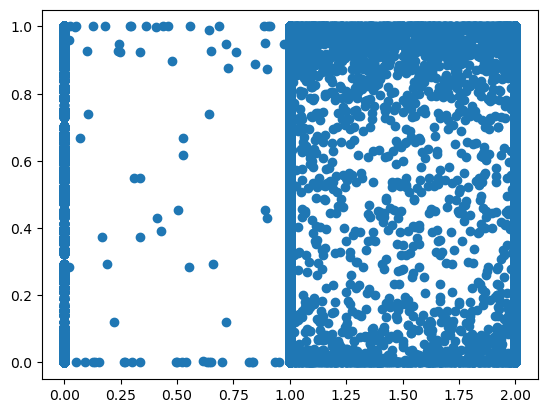

In [102]:
plt.scatter(x=atl06sr_gdf['segment_snowcover'], y=atl06sr_gdf['reanalysis_sca'])

In [106]:
atl06sr_gdf['segment_snowcover'].unique()

array([1.        , 2.        , 1.08823529, ..., 1.21568627, 1.42696629,
       1.98924731], shape=(1570,))

### Get the number of data points we have for each subsetting iteration:

In [95]:
atl06sr_gdf.shape

(4672860, 46)

In [97]:
atl06sr_gdf[atl06sr_gdf['slope']<20].shape

(3349762, 46)

In [96]:
atl06sr_gdf_fsca_9.shape

(568323, 47)

In [98]:
atl06sr_gdf_fsca_9[atl06sr_gdf_fsca_9['n']>100].shape

(567732, 47)

In [99]:
atl06sr_gdf_fsca_9[atl06sr_gdf_fsca_9['n']>300].shape

(564663, 47)

In [100]:
atl06sr_gdf_fsca_9[atl06sr_gdf_fsca_9['n']>500].shape

(560645, 47)

### Run an experiment to sample ICESat-2 data on one date at different sample sizes:

In [226]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask'],
      dtype='object')

In [227]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [240]:
atl06sr_gdf['is2_r_diff'] = atl06sr_gdf['icesat2_3dep_dif'] - atl06sr_gdf['reanalysis_sd']

In [315]:
highlight_date = [pd.to_datetime('2021-04-01'), pd.to_datetime('2021-04-07')]

In [269]:
atl06_highlight_data = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['acqdate_dt'].isin([highlight_date[0]])) & (atl06sr_gdf['slope']<20)]

In [316]:
atl06_highlight_data2 = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['acqdate_dt'].isin([highlight_date[1]])) & (atl06sr_gdf['slope']<20)]

In [270]:
sample1 = atl06_highlight_data['is2_r_diff'].sample(n=10)

In [244]:
np.nanmedian(sample1)

np.float64(-1.7496050983090754)

<Axes: >

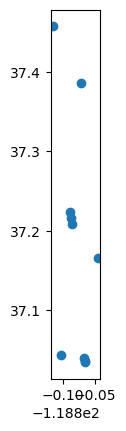

In [233]:
sample1.plot()

<Axes: >

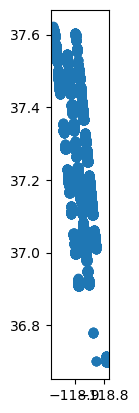

In [234]:
atl06_highlight_data.plot()

### Test for one date:

In [299]:
numbers_and_repeats = [(10, 100), (25, 100), (50, 100), (75, 100), (100, 100) , (150, 100) , (200, 100), (250, 100), (300, 100), (350, 100), (400, 100), (450, 100), (500, 100)] # (number, repetitions)
repeated_list = []

for num, reps in numbers_and_repeats:
    repeated_list.extend([num] * reps)

numbers_and_repeats

sample_num = [i for _ in range(len(numbers_and_repeats)) for i in range(1, 101)]

In [304]:
sample_ranges = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]

sample_df = pd.DataFrame({'sample_size': repeated_list, 'sample_num': sample_num})

sample_df['median'] = np.nan

for sample_size in sample_df['sample_size'].unique():
    sampled_values_ens = []
    for num in range(100):
        sample = atl06_highlight_data['is2_r_diff'].sample(n=sample_size)
        sample_median = np.nanmedian(sample.values)
        #sampled_values_ens.append(sample_median)
        sample_df.loc[(sample_df['sample_size']==sample_size) & (sample_df['sample_num']==num), 'median'] = sample_median

In [310]:
sample_chart = alt.Chart(sample_df).mark_point().encode(
    x=alt.X('sample_size:Q', title='Sample Size'),
    y=alt.Y('median:Q', title='Median ICESat-2 - Reanalysis Snow Depth Difference (m)', scale=alt.Scale(domain=[-1, 1])),
    color=alt.Color('sample_size:O', title='Sample Size', scale=alt.Scale(scheme='rainbow'))
).properties(
    title='Effect of Sample Size on Median Snow Depth Difference Estimate'
)

sample_chart

alt.Chart(...)

In [311]:
sampled_values_10 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=10)
    sample_median = np.nanmedian(sample.values)
    sampled_values_10.append(sample_median)

sampled_values_20 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=20)
    sample_median = np.nanmedian(sample.values)
    sampled_values_20.append(sample_median)

sampled_values_50 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=50)
    sample_median = np.nanmedian(sample.values)
    sampled_values_50.append(sample_median)

sampled_values_100 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=100)
    sample_median = np.nanmedian(sample.values)
    sampled_values_100.append(sample_median)

sampled_values_1000 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=1000)
    sample_median = np.nanmedian(sample.values)
    sampled_values_1000.append(sample_median)

sampled_values_1500 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=1500)
    sample_median = np.nanmedian(sample.values)
    sampled_values_5000.append(sample_median)

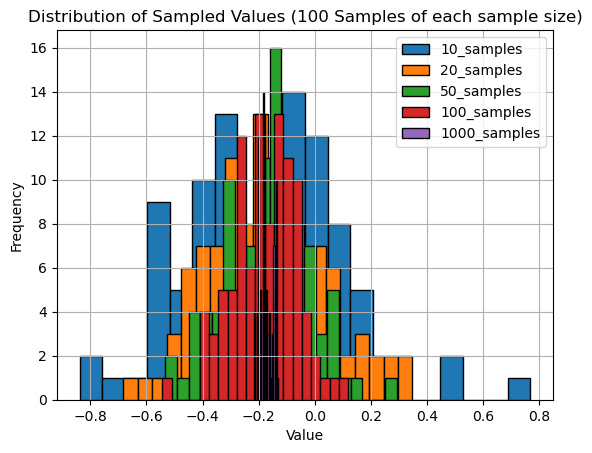

In [314]:
fig, ax = plt.subplots()
plt.hist(sampled_values_10, bins=20, edgecolor='black', label='10_samples')
plt.hist(sampled_values_20, bins=20, edgecolor='black', label='20_samples')
plt.hist(sampled_values_50, bins=20, edgecolor='black', label='50_samples')
plt.hist(sampled_values_100, bins=20, edgecolor='black', label='100_samples')
plt.hist(sampled_values_1000, bins=20, edgecolor='black', label='1000_samples')
#plt.hist(sampled_values_1500, bins=20, edgecolor='black', label='1500_samples')
plt.title('Distribution of Sampled Values (100 Samples of each sample size)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.show()

### Test for a second date:

In [317]:
numbers_and_repeats = [(10, 100), (25, 100), (50, 100), (75, 100), (100, 100) , (150, 100) , (200, 100), (250, 100), (300, 100), (350, 100), (400, 100), (450, 100), (500, 100)] # (number, repetitions)
repeated_list = []

for num, reps in numbers_and_repeats:
    repeated_list.extend([num] * reps)

numbers_and_repeats

sample_num = [i for _ in range(len(numbers_and_repeats)) for i in range(1, 101)]

In [318]:
sample_ranges = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]

sample_df = pd.DataFrame({'sample_size': repeated_list, 'sample_num': sample_num})

sample_df['median'] = np.nan

for sample_size in sample_df['sample_size'].unique():
    sampled_values_ens = []
    for num in range(100):
        sample = atl06_highlight_data2['is2_r_diff'].sample(n=sample_size)
        sample_median = np.nanmedian(sample.values)
        #sampled_values_ens.append(sample_median)
        sample_df.loc[(sample_df['sample_size']==sample_size) & (sample_df['sample_num']==num), 'median'] = sample_median

In [319]:
sample_chart = alt.Chart(sample_df).mark_point().encode(
    x=alt.X('sample_size:Q', title='Sample Size'),
    y=alt.Y('median:Q', title='Median ICESat-2 - Reanalysis Snow Depth Difference (m)', scale=alt.Scale(domain=[-1, 1])),
    color=alt.Color('sample_size:O', title='Sample Size', scale=alt.Scale(scheme='rainbow'))
).properties(
    title='Effect of Sample Size on Median Snow Depth Difference Estimate'
)

sample_chart

alt.Chart(...)

In [320]:
sampled_values_10 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=10)
    sample_median = np.nanmedian(sample.values)
    sampled_values_10.append(sample_median)

sampled_values_20 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=20)
    sample_median = np.nanmedian(sample.values)
    sampled_values_20.append(sample_median)

sampled_values_50 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=50)
    sample_median = np.nanmedian(sample.values)
    sampled_values_50.append(sample_median)

sampled_values_100 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=100)
    sample_median = np.nanmedian(sample.values)
    sampled_values_100.append(sample_median)

sampled_values_1000 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=1000)
    sample_median = np.nanmedian(sample.values)
    sampled_values_1000.append(sample_median)

sampled_values_1500 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=1500)
    sample_median = np.nanmedian(sample.values)
    sampled_values_5000.append(sample_median)

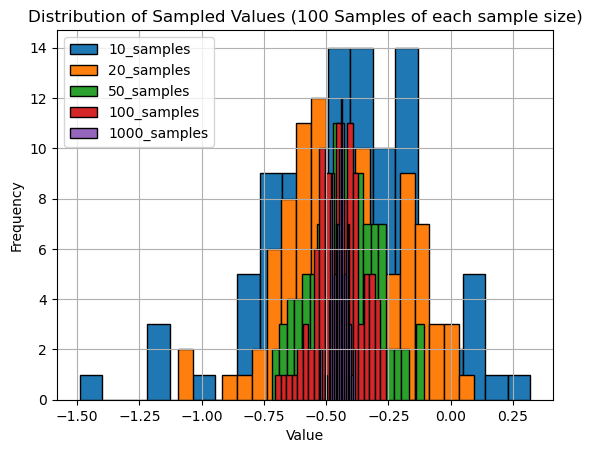

In [321]:
fig, ax = plt.subplots()
plt.hist(sampled_values_10, bins=20, edgecolor='black', label='10_samples')
plt.hist(sampled_values_20, bins=20, edgecolor='black', label='20_samples')
plt.hist(sampled_values_50, bins=20, edgecolor='black', label='50_samples')
plt.hist(sampled_values_100, bins=20, edgecolor='black', label='100_samples')
plt.hist(sampled_values_1000, bins=20, edgecolor='black', label='1000_samples')
#plt.hist(sampled_values_1500, bins=20, edgecolor='black', label='1500_samples')
plt.title('Distribution of Sampled Values (100 Samples of each sample size)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.show()

### Exploratory plots at different slopes and snow cover amounts:

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Text(0.5, 1.0, 'By Elevation, with all slopes and fsca > 0.9')

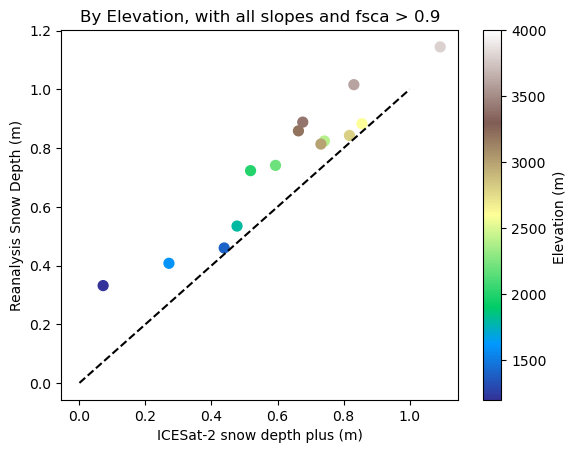

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and fsca > 0.9')

### same as above, using segment_snowcover instead of fsca:

Text(0.5, 1.0, 'By Elevation, with all slopes and segment_snowcover == 2 (full snow cover)')

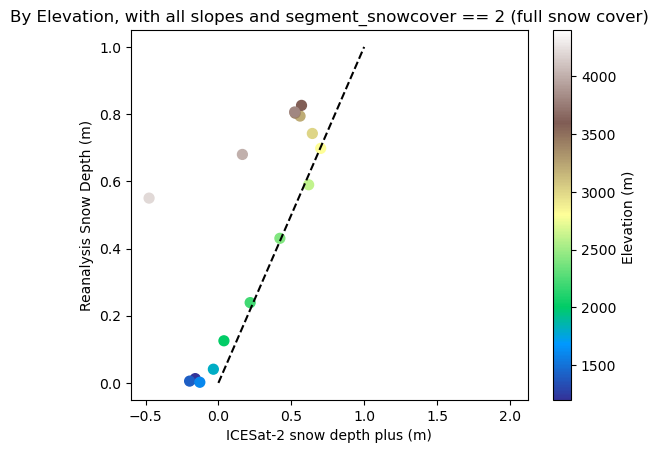

In [110]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['segment_snowcover']==2) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['segment_snowcover']==2) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and segment_snowcover == 2 (full snow cover)')

Text(0.5, 1.0, 'By Elevation, with all slopes and all fsca values')

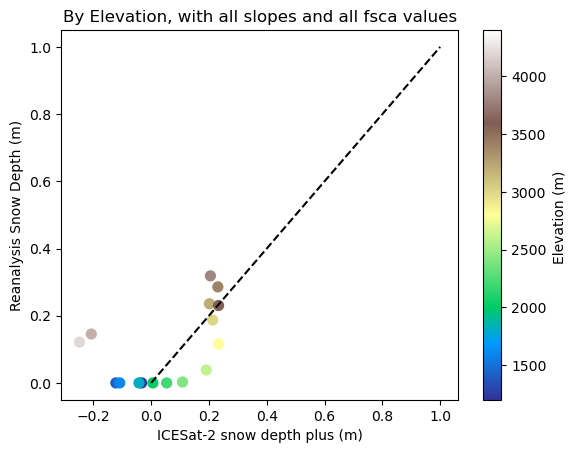

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and all fsca values')

(-0.5, 1.3)

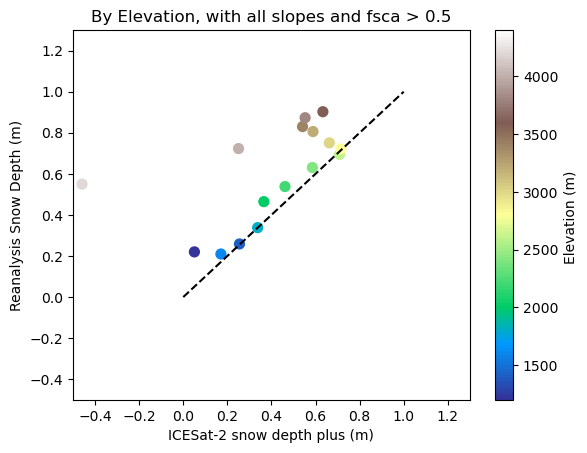

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and fsca > 0.5')
plt.xlim(-0.5, 1.3)
plt.ylim(-0.5, 1.3)

(0.0, 1.3)

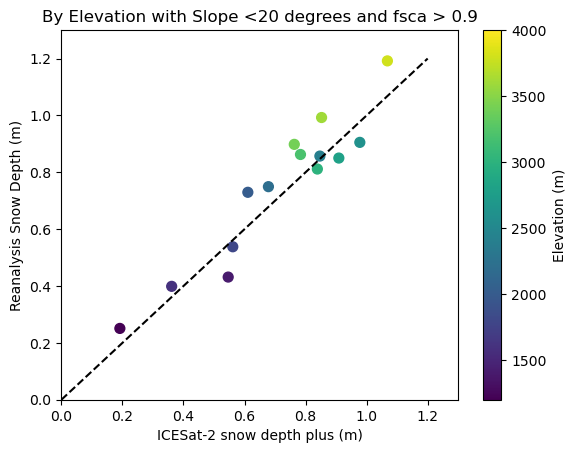

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1.2, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and fsca > 0.9')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

### same as above but with segment snow cover instead of fsca

(0.0, 1.3)

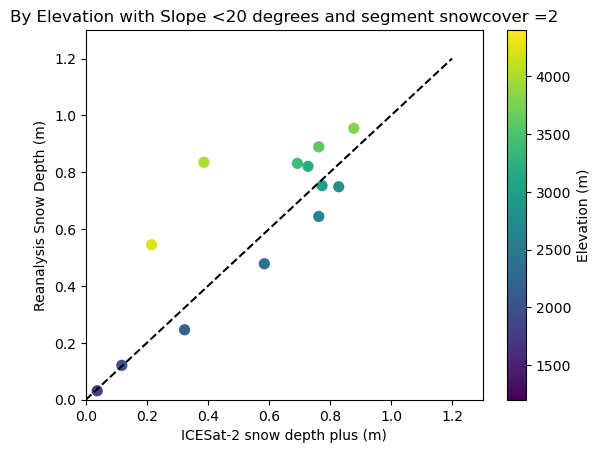

In [112]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['segment_snowcover']==2) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['segment_snowcover']==2) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1.2, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and segment snowcover =2')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

(0.0, 1.3)

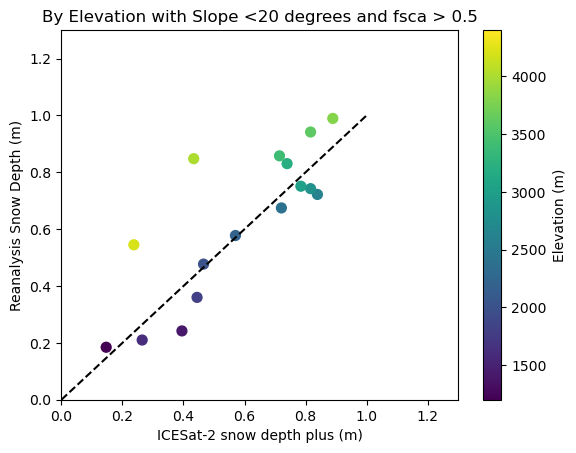

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and fsca > 0.5')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

(0.0, 1.3)

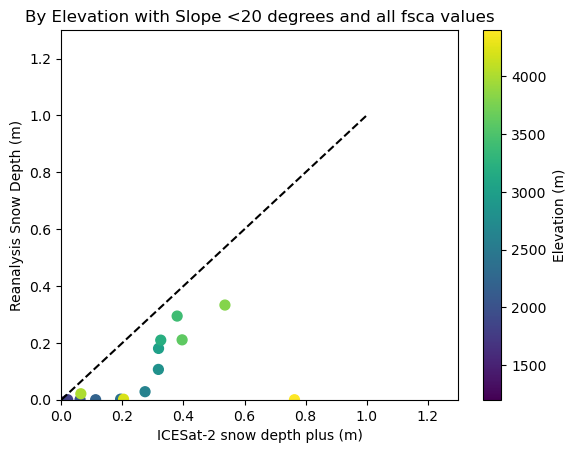

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and all fsca values')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

### Plot slope:

Text(0.5, 1.0, 'By Slope, with all Elevations and fsca >0.9')

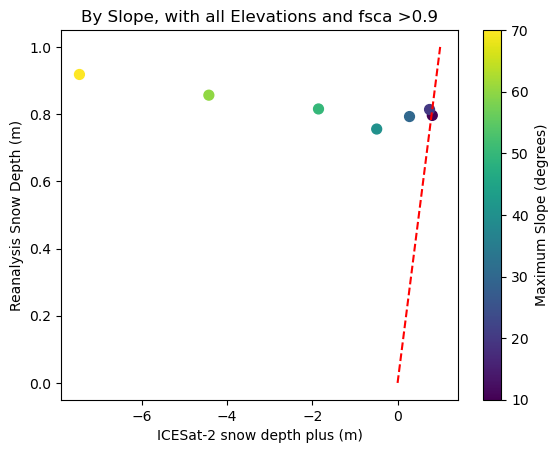

In [ ]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and fsca >0.9')

Text(0.5, 1.0, 'By Slope, with all Elevations and fsca >0.5')

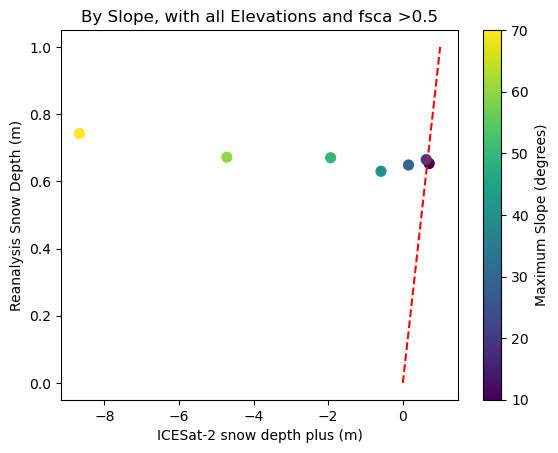

In [ ]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and fsca >0.5')

Text(0.5, 1.0, 'By Slope, with all Elevations and all fsca values')

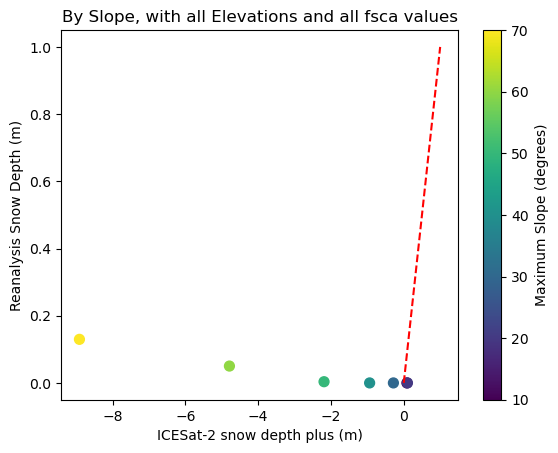

In [ ]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and all fsca values')